# Analisis E-Commerce Olist: Pertumbuhan, Operasional, dan Nilai Pelanggan

**Notebook portofolio — versi disempurnakan**  
Analisis end-to-end atas Brazilian E-Commerce Public Dataset by Olist, dengan fokus pada akurasi grain data, insight bisnis, dan reproducibility.

> **Prinsip utama:** tabel item, pembayaran, dan ulasan tidak digabung mentah pada satu master table karena relasi one-to-many dapat menggandakan pendapatan, item, dan nilai RFM. Notebook ini membangun fact table terpisah sesuai unit analisisnya.

## Ringkasan penyempurnaan

Notebook ini meningkatkan versi awal melalui:

- pencarian file lokal yang fleksibel dan validasi apakah CSV terpotong;
- audit skema, missing value, duplikasi, key uniqueness, dan referential integrity;
- pembuatan **order-level fact table** dan **item-level fact table** untuk mencegah double counting;
- rekonsiliasi pembayaran dengan harga produk + ongkir;
- KPI eksekutif, tren waktu, kategori, wilayah, dan metode pembayaran;
- analisis hubungan keterlambatan dengan rating menggunakan uji nonparametrik;
- segmentasi pelanggan berbasis RFM, cohort retention, dan analisis konsentrasi seller;
- rekomendasi yang dihitung dinamis dari hasil analisis.

## Pertanyaan bisnis

1. Bagaimana skala, pertumbuhan, dan pola bulanan bisnis?
2. Kategori apa yang unggul dari sisi unit terjual dan GMV?
3. Seberapa kuat keterlambatan pengiriman berkaitan dengan rating rendah?
4. Wilayah pelanggan mana yang paling besar dan mana yang memiliki risiko layanan?
5. Seberapa sehat retensi pelanggan dan segmen mana yang paling bernilai?
6. Bagaimana komposisi pembayaran dan konsentrasi GMV di antara seller?

**Definisi metrik:** `Product GMV` = jumlah harga item (tidak termasuk freight); `order value` = harga produk + freight; `total payment` = nilai pembayaran pelanggan; `AOV` = total order value / jumlah delivered order unik; `rating rata-rata` = rata-rata skor ulasan pada level order; `repeat customer` = customer dengan ≥2 delivered order sepanjang riwayat; dan `on-time` = tanggal diterima tidak melewati tanggal estimasi.

## Panduan membaca notebook

Agar alur analisis mudah diikuti, setiap **cell kode** memiliki struktur yang sama:

1. **Tujuan** menjelaskan pertanyaan yang ingin diselesaikan.
2. **Tindakan yang dilakukan** menguraikan transformasi atau perhitungan di dalam kode.
3. **Alasan** menjelaskan dasar metodologis atau pertimbangan bisnisnya.
4. **Output yang diharapkan** memberi gambaran hasil cell sebelum kode dijalankan.
5. **Interpretasi output** menjelaskan arti hasil setelah cell dijalankan.

Cell Markdown lain berfungsi sebagai konteks bab, definisi metrik, keputusan metodologis, dan batasan analisis. Dengan pola ini, pembaca dapat memahami *apa*, *mengapa*, serta *makna hasilnya* tanpa harus menebak fungsi setiap potongan kode.

# **1. Persiapan dan pemuatan data**

## **1.1 Inisialisasi Environment dan Fungsi Bantu**

**Tujuan:** Menyiapkan seluruh library, gaya visual, serta fungsi format yang akan digunakan secara konsisten sampai akhir notebook.

**Tindakan yang dilakukan:**

1. Mengimpor library pengolahan data, visualisasi, statistik, dan tampilan Markdown.
2. Mengatur peringatan, format angka pandas, palet warna, dan tema grafik.
3. Membuat fungsi `format_brl()`, `pct()`, dan `format_table()` agar mata uang, persentase, serta tabel memiliki format seragam.
4. Menampilkan versi Python dan library analitik utama untuk dokumentasi reproducibility.

**Alasan:** Konfigurasi terpusat mencegah pengulangan kode dan membuat seluruh visual serta angka lebih konsisten.

**Environment target:** Python 3.11 dengan dependency notebook yang dikunci melalui `requirements-notebook.txt`. Environment pengembangan dan eksekusi lengkap tersedia melalui `requirements-dev.txt`.

In [1]:
from pathlib import Path
import os
import platform
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import scipy
from scipy.stats import mannwhitneyu, spearmanr
from IPython.display import display, Markdown

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")

# Palet yang konsisten untuk seluruh notebook
NAVY = "#16324F"
BLUE = "#2F80ED"
TEAL = "#00A6A6"
ORANGE = "#F2994A"
RED = "#D1495B"
GREY = "#7A8899"
LIGHT = "#EAF2F8"

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.figsize": (12, 6),
    "figure.dpi": 110,
    "axes.titleweight": "bold",
    "axes.titlesize": 14,
    "axes.labelsize": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "legend.frameon": False,
})

def format_brl(value):
    '''Format ringkas mata uang Brazilian Real.'''
    if pd.isna(value):
        return "—"
    if abs(value) >= 1_000_000:
        return f"R$ {value / 1_000_000:,.2f}M"
    if abs(value) >= 1_000:
        return f"R$ {value / 1_000:,.1f}K"
    return f"R$ {value:,.2f}"

def pct(value, decimals=1):
    return f"{value:.{decimals}%}" if pd.notna(value) else "—"

def format_table(frame, formatters):
    '''Menghasilkan salinan tabel dengan format presentasi tanpa mengubah data sumber.'''
    result = frame.copy()
    for column, formatter in formatters.items():
        if callable(formatter):
            result[column] = result[column].map(formatter)
        else:
            result[column] = result[column].map(
                lambda value, template=formatter: template.format(value) if pd.notna(value) else "—"
            )
    return result

print(
    f"Python {platform.python_version()} | pandas {pd.__version__} | "
    f"numpy {np.__version__} | scipy {scipy.__version__} | "
    f"matplotlib {plt.matplotlib.__version__} | seaborn {sns.__version__}"
)

Python 3.11.15 | pandas 2.3.3 | numpy 2.3.5 | scipy 1.17.0 | matplotlib 3.11.1 | seaborn 0.13.2


## **1.2 Resolusi Path, Pemuatan, dan Validasi Kelengkapan CSV**

**Tujuan:** Memastikan sembilan dataset Olist ditemukan dan benar-benar lengkap sebelum analisis dilakukan.

**Tindakan yang dilakukan:**

1. Mendefinisikan nama seluruh file serta ambang minimum jumlah baris.
2. Mencari file secara berurutan melalui environment variable, folder `project_sources/`, folder `data/`, dan folder kerja saat ini.
3. Mendukung filename asli maupun filename yang memiliki awalan nomor.
4. Membaca seluruh CSV ke dictionary `tables` dan menghentikan proses jika ada file yang terpotong.

**Alasan:** Analisis yang tampak benar tetap dapat menghasilkan insight keliru apabila sumber data terpotong atau notebook hanya bekerja pada satu struktur folder tertentu.

In [2]:
DATASET_FILES = {
    "customers": "customers_dataset.csv",
    "sellers": "sellers_dataset.csv",
    "payments": "order_payments_dataset.csv",
    "translation": "product_category_name_translation.csv",
    "products": "products_dataset.csv",
    "geolocation": "geolocation_dataset.csv",
    "reviews": "order_reviews_dataset.csv",
    "items": "order_items_dataset.csv",
    "orders": "orders_dataset.csv",
}

# Ambang ini menangkap file yang terpotong saat upload, bukan untuk menyaring baris analisis.
EXPECTED_MIN_ROWS = {
    "customers": 99_000,
    "sellers": 3_000,
    "payments": 103_000,
    "translation": 70,
    "products": 32_000,
    "geolocation": 1_000_000,
    "reviews": 99_000,
    "items": 112_000,
    "orders": 99_000,
}

search_roots = []
if os.getenv("ECOMMERCE_DATA_DIR"):
    search_roots.append(Path(os.environ["ECOMMERCE_DATA_DIR"]))
search_roots.extend([Path.cwd() / "project_sources", Path.cwd() / "data", Path.cwd()])

def resolve_dataset(filename):
    for root in search_roots:
        if not root.exists():
            continue
        direct = root / filename
        if direct.exists():
            return direct
        prefixed = sorted(root.glob(f"*{filename}"))
        if prefixed:
            return prefixed[0]
    roots = "\n- ".join(str(path.resolve()) for path in search_roots)
    raise FileNotFoundError(f"{filename} tidak ditemukan. Folder yang diperiksa:\n- {roots}")

dataset_paths = {name: resolve_dataset(filename) for name, filename in DATASET_FILES.items()}
tables = {name: pd.read_csv(path) for name, path in dataset_paths.items()}

truncated = {
    name: len(df)
    for name, df in tables.items()
    if len(df) < EXPECTED_MIN_ROWS[name]
}
if truncated:
    details = ", ".join(f"{name}={rows:,} baris" for name, rows in truncated.items())
    raise ValueError(
        "Ada CSV yang tampaknya terpotong: " + details +
        ". Unduh/unggah ulang file lengkap sebelum melanjutkan."
    )

print(f"Berhasil memuat {len(tables)} dataset lengkap.")

Berhasil memuat 9 dataset lengkap.


## **1.3 Audit awal ukuran dan kualitas setiap tabel**

**Tujuan:** Mendapatkan gambaran awal mengenai ukuran, missing value, duplikasi persis, dan penggunaan memori setiap dataset.

**Tindakan yang dilakukan:**

1. Membuat salinan kerja masing-masing tabel agar data sumber tetap terjaga.
2. Menghitung jumlah baris, kolom, missing cells, exact duplicates, dan memory usage.
3. Mengurutkan hasil audit berdasarkan jumlah baris dan menampilkannya dalam satu tabel ringkas.

**Alasan:** Audit awal menentukan strategi cleaning dan membantu membedakan missing value yang wajar dari masalah kualitas data.

In [3]:
customers = tables["customers"].copy()
sellers = tables["sellers"].copy()
payments = tables["payments"].copy()
translation = tables["translation"].copy()
products = tables["products"].copy()
geolocation = tables["geolocation"].copy()
reviews = tables["reviews"].copy()
items = tables["items"].copy()
orders = tables["orders"].copy()

audit = pd.DataFrame({
    "rows": {name: len(df) for name, df in tables.items()},
    "columns": {name: df.shape[1] for name, df in tables.items()},
    "missing_cells": {name: int(df.isna().sum().sum()) for name, df in tables.items()},
    "exact_duplicates": {name: int(df.duplicated().sum()) for name, df in tables.items()},
    "memory_mb": {name: df.memory_usage(deep=True).sum() / 1024**2 for name, df in tables.items()},
}).sort_values("rows", ascending=False)

display(format_table(audit, {
    "rows": "{:,.0f}",
    "columns": "{:,.0f}",
    "missing_cells": "{:,.0f}",
    "exact_duplicates": "{:,.0f}",
    "memory_mb": "{:,.2f}",
}))

,rows,columns,missing_cells,exact_duplicates,memory_mb
geolocation,"1,000,163",5,0,"261,831",146.09
items,"112,650",7,0,0,39.43
payments,"103,886",5,0,0,17.81
customers,"99,441",5,0,0,29.62
orders,"99,441",8,"4,908",0,58.97
reviews,"99,224",7,"145,903",0,42.74
products,"32,951",9,"2,448",0,6.79
sellers,"3,095",4,0,0,0.66
translation,71,2,0,0,0.01


**Interpretasi:**
- Geolocation merupakan tabel terbesar dengan 1.000.163 baris dan 261.831 duplikasi persis.
- Reviews memiliki 145.903 missing cells karena judul dan komentar bersifat opsional.
- Orders memiliki 4.908 missing cells yang terutama berkaitan dengan tahapan order yang belum selesai
- Kondisi ini perlu ditangani berdasarkan konteks, bukan diisi sembarangan.

Missing value pada tanggal pengiriman wajar untuk pesanan yang belum selesai. Komentar ulasan juga bersifat opsional, sehingga tidak diimputasi sebagai teks palsu. Duplikasi persis pada geolocation akan dihapus, kemudian beberapa koordinat dalam satu prefix kode pos diringkas dengan median—lebih stabil daripada mengambil baris pertama.

## **1.4 Validasi Primary Key dan Referential Integrity**

**Tujuan:** Memastikan hubungan antartabel aman sebelum proses merge dilakukan.

**Tindakan yang dilakukan:**

1. Menguji keunikan key utama pada customers, orders, products, sellers, items, dan payments.
2. Memastikan seluruh foreign key order, customer, product, seller, payment, dan review memiliki pasangan di tabel induknya.
3. Menjalankan `assert` agar notebook berhenti bila satu saja pemeriksaan gagal.

**Alasan:** Merge tanpa validasi dapat menghilangkan baris, menggandakan nilai, atau menghubungkan record yang salah.


In [4]:
integrity_checks = pd.DataFrame([
    ("customers.customer_id unik", customers["customer_id"].is_unique),
    ("orders.order_id unik", orders["order_id"].is_unique),
    ("orders.customer_id unik", orders["customer_id"].is_unique),
    ("products.product_id unik", products["product_id"].is_unique),
    ("sellers.seller_id unik", sellers["seller_id"].is_unique),
    ("items (order_id, order_item_id) unik", ~items.duplicated(["order_id", "order_item_id"]).any()),
    ("payments (order_id, payment_sequential) unik", ~payments.duplicated(["order_id", "payment_sequential"]).any()),
    ("semua order memiliki customer", set(orders["customer_id"]) <= set(customers["customer_id"])),
    ("semua item merujuk order", set(items["order_id"]) <= set(orders["order_id"])),
    ("semua payment merujuk order", set(payments["order_id"]) <= set(orders["order_id"])),
    ("semua review merujuk order", set(reviews["order_id"]) <= set(orders["order_id"])),
    ("semua item memiliki product", set(items["product_id"]) <= set(products["product_id"])),
    ("semua item memiliki seller", set(items["seller_id"]) <= set(sellers["seller_id"])),
], columns=["check", "valid"])

assert integrity_checks["valid"].all(), "Referential integrity gagal; periksa sumber data."
display(integrity_checks.assign(status=np.where(integrity_checks["valid"], "PASS", "FAIL"))[["check", "status"]])

,check,status
0,customers.customer_id unik,PASS
1,orders.order_id unik,PASS
2,orders.customer_id unik,PASS
3,products.product_id unik,PASS
4,sellers.seller_id unik,PASS
5,"items (order_id, order_item_id) unik",PASS
6,"payments (order_id, payment_sequential) unik",PASS
7,semua order memiliki customer,PASS
8,semua item merujuk order,PASS
9,semua payment merujuk order,PASS


**Interpretasi:**

Semua 13 pemeriksaan berstatus PASS. Struktur relasi dasar dataset konsisten, sehingga proses merge selanjutnya dapat dilakukan dengan parameter `validate` yang eksplisit. `review_id` tidak dipaksakan unik karena satu order dapat mempunyai struktur review yang perlu diagregasi pada level order.

# **2. Cleaning, Feature Engineering, dan Analytical Fact Tables**

## **2.1 Cleaning Tanggal, Kategori, Komentar, dan Geolocation**

**Tujuan:** Menyiapkan tipe data dan label yang konsisten tanpa melakukan imputasi yang tidak memiliki dasar bisnis.

**Tindakan yang dilakukan:**

1. Mengonversi seluruh kolom tanggal order, item, dan review menjadi datetime.
2. Memperbaiki typo nama kolom `lenght` menjadi `length`.
3. Menggabungkan terjemahan kategori dan menggunakan nama Portugis atau `unknown` sebagai fallback.
4. Membuat indikator `has_comment` tanpa mengubah komentar kosong menjadi teks buatan.
5. Menghapus nilai kosong dan duplikasi persis geolocation, membuang koordinat di luar bounding box Brasil, lalu merangkum koordinat per prefix kode pos menggunakan median.

**Alasan:** Datetime dibutuhkan untuk analisis waktu, sedangkan median koordinat lebih stabil daripada mengambil baris pertama. Outlier spasial dibuang sebelum median dihitung agar koordinat agregat konsisten dengan dashboard. Missing value tidak diimputasi apabila tidak diperlukan untuk KPI.

In [5]:
# Tanggal dikonversi secara eksplisit; errors='coerce' membuat nilai invalid mudah diaudit.
order_date_columns = [
    "order_purchase_timestamp", "order_approved_at", "order_delivered_carrier_date",
    "order_delivered_customer_date", "order_estimated_delivery_date",
]
for column in order_date_columns:
    orders[column] = pd.to_datetime(orders[column], errors="coerce")

items["shipping_limit_date"] = pd.to_datetime(items["shipping_limit_date"], errors="coerce")
reviews["review_creation_date"] = pd.to_datetime(reviews["review_creation_date"], errors="coerce")
reviews["review_answer_timestamp"] = pd.to_datetime(reviews["review_answer_timestamp"], errors="coerce")

products = products.rename(columns={
    "product_name_lenght": "product_name_length",
    "product_description_lenght": "product_description_length",
})

# Tidak mengimputasi dimensi produk karena tidak diperlukan untuk KPI utama.
# Kategori yang tidak memiliki terjemahan dipertahankan dengan fallback ke nama Portugis.
products = products.merge(translation, on="product_category_name", how="left", validate="many_to_one")
products["category"] = (
    products["product_category_name_english"]
    .fillna(products["product_category_name"])
    .fillna("unknown")
)

reviews["has_comment"] = reviews["review_comment_message"].notna()

# Satu prefix dapat memiliki banyak titik. Urutan cleaning disamakan dengan dashboard:
# nilai kosong → exact duplicate pada seluruh kolom → bounding box Brasil → median.
BRAZIL_LATITUDE_BOUNDS = (-34.0, 6.0)
BRAZIL_LONGITUDE_BOUNDS = (-74.0, -34.0)
geo_required = [
    "geolocation_zip_code_prefix", "geolocation_lat", "geolocation_lng",
]
geolocation_clean = (
    geolocation.dropna(subset=geo_required)
    .drop_duplicates()
    .loc[:, geo_required]
    .copy()
)
geolocation_clean["geolocation_lat"] = pd.to_numeric(
    geolocation_clean["geolocation_lat"], errors="coerce"
)
geolocation_clean["geolocation_lng"] = pd.to_numeric(
    geolocation_clean["geolocation_lng"], errors="coerce"
)
geolocation_clean = geolocation_clean.dropna(subset=["geolocation_lat", "geolocation_lng"])
valid_geo = (
    geolocation_clean["geolocation_lat"].between(*BRAZIL_LATITUDE_BOUNDS)
    & geolocation_clean["geolocation_lng"].between(*BRAZIL_LONGITUDE_BOUNDS)
)
geolocation_clean = geolocation_clean.loc[valid_geo].copy()
geo_zip = (
    geolocation_clean.groupby("geolocation_zip_code_prefix", as_index=False)
    .agg(
        geolocation_lat=("geolocation_lat", "median"),
        geolocation_lng=("geolocation_lng", "median"),
    )
)

invalid_dates = {column: int(orders[column].isna().sum()) for column in order_date_columns}
print("Missing timestamp setelah konversi:", invalid_dates)
print(
    f"Geolocation: {len(geolocation):,} baris awal → "
    f"{len(geolocation_clean):,} baris digunakan → "
    f"{len(geo_zip):,} prefix kode pos unik"
)

Missing timestamp setelah konversi: {'order_purchase_timestamp': 0, 'order_approved_at': 160, 'order_delivered_carrier_date': 1783, 'order_delivered_customer_date': 2965, 'order_estimated_delivery_date': 0}
Geolocation: 1,000,163 baris awal → 738,299 baris digunakan → 19,010 prefix kode pos unik


**Interpretasi:**

Tanggal pembelian dan estimasi lengkap, sedangkan tanggal approval atau pengiriman masih memiliki missing value karena tidak semua order mencapai tahap tersebut. Pembersihan geolocation mempertahankan 738.299 baris valid dan merangkumnya menjadi 19.010 prefix kode pos unik. Tidak ada median koordinat di luar bounding box Brasil, sehingga basis spasial notebook konsisten dengan dashboard.

## **2.2 Membangun Fact Table Sesuai Grain Analisis**

**Tujuan:** Mencegah double counting dengan memisahkan data pada level order, item, dan order-seller.

**Tindakan yang dilakukan:**

1. Memperkaya item dengan kategori dan atribut produk.
2. Mengagregasi item, payment, dan review ke level `order_id` sebelum digabungkan.
3. Membangun `order_fact` untuk KPI order dan customer, `item_fact` untuk unit serta kategori, dan `seller_order_fact` untuk performa seller.
4. Membuat fitur order value, delivery days, delay days, on-time status, bulan, tahun, dan hari pembelian.
5. Menjalankan assertion untuk memastikan jumlah order dan total harga item tetap konsisten.
6. Membentuk subset delivered order sebagai basis analisis penjualan selesai.

**Alasan:** Satu order dapat memiliki banyak item, payment record, dan review. Menggabungkan semuanya secara mentah akan menggandakan GMV, payment, serta nilai RFM.

**Output yang diharapkan:** Jumlah baris tiap fact table dan jumlah delivered records.

Mengapa memakai beberapa fact table?

| Fact table | Grain | Digunakan untuk |
|---|---|---|
| `order_fact` | satu baris per order | KPI, waktu, pembayaran, review, customer, wilayah |
| `item_fact` | satu baris per item | unit, GMV produk, kategori, seller |
| `seller_order_fact` | satu baris per kombinasi order–seller | performa dan konsentrasi seller |

Pembayaran dan review diagregasi ke `order_id` **sebelum** digabung dengan order. Ini menghindari Cartesian multiplication ketika satu order memiliki beberapa item, payment record, atau review.

In [6]:
item_enriched = items.merge(
    products[["product_id", "category", "product_weight_g", "product_length_cm", "product_height_cm", "product_width_cm"]],
    on="product_id", how="left", validate="many_to_one"
)

item_order_agg = (
    item_enriched.groupby("order_id", as_index=False)
    .agg(
        item_count=("order_item_id", "size"),
        unique_products=("product_id", "nunique"),
        seller_count=("seller_id", "nunique"),
        product_gmv=("price", "sum"),
        freight_value=("freight_value", "sum"),
    )
)

payment_order_agg = (
    payments.groupby("order_id", as_index=False)
    .agg(
        payment_value=("payment_value", "sum"),
        payment_records=("payment_sequential", "size"),
        max_installments=("payment_installments", "max"),
        payment_methods=("payment_type", lambda x: ", ".join(sorted(set(x)))),
    )
)

review_order_agg = (
    reviews.groupby("order_id", as_index=False)
    .agg(
        review_score=("review_score", "mean"),
        review_count=("review_id", "size"),
        has_comment=("has_comment", "max"),
    )
)

order_fact = (
    orders.merge(customers, on="customer_id", how="left", validate="one_to_one")
    .merge(item_order_agg, on="order_id", how="left", validate="one_to_one")
    .merge(payment_order_agg, on="order_id", how="left", validate="one_to_one")
    .merge(review_order_agg, on="order_id", how="left", validate="one_to_one")
)

order_fact["order_value"] = order_fact["product_gmv"] + order_fact["freight_value"]
order_fact["delivery_days"] = (
    order_fact["order_delivered_customer_date"] - order_fact["order_purchase_timestamp"]
).dt.total_seconds() / 86_400
order_fact["delay_days"] = (
    order_fact["order_delivered_customer_date"] - order_fact["order_estimated_delivery_date"]
).dt.total_seconds() / 86_400
order_fact["on_time"] = (
    order_fact["delay_days"].le(0).where(order_fact["delay_days"].notna()).astype("boolean")
)
order_fact["purchase_month"] = order_fact["order_purchase_timestamp"].dt.to_period("M").dt.to_timestamp()
order_fact["purchase_year"] = order_fact["order_purchase_timestamp"].dt.year
order_fact["purchase_weekday"] = order_fact["order_purchase_timestamp"].dt.day_name()

item_fact = (
    item_enriched.merge(
        orders[["order_id", "customer_id", "order_status", "order_purchase_timestamp"]],
        on="order_id", how="left", validate="many_to_one"
    )
    .merge(
        customers[["customer_id", "customer_unique_id", "customer_state", "customer_city"]],
        on="customer_id", how="left", validate="many_to_one"
    )
)

seller_order_fact = (
    item_enriched.groupby(["order_id", "seller_id"], as_index=False)
    .agg(items=("order_item_id", "size"), seller_gmv=("price", "sum"))
    .merge(
        order_fact[["order_id", "order_status", "review_score", "on_time", "delay_days"]],
        on="order_id", how="left", validate="many_to_one"
    )
    .merge(sellers, on="seller_id", how="left", validate="many_to_one")
)

assert len(order_fact) == len(orders)
assert order_fact["order_id"].is_unique
assert np.isclose(item_fact["price"].sum(), items["price"].sum())

delivered = order_fact.loc[order_fact["order_status"].eq("delivered")].copy()
delivered_items = item_fact.loc[item_fact["order_status"].eq("delivered")].copy()
delivered_seller_orders = seller_order_fact.loc[seller_order_fact["order_status"].eq("delivered")].copy()

print(f"order_fact: {len(order_fact):,} baris | item_fact: {len(item_fact):,} baris")
print(f"Delivered orders: {len(delivered):,} | delivered items: {len(delivered_items):,}")

order_fact: 99,441 baris | item_fact: 112,650 baris
Delivered orders: 96,478 | delivered items: 110,197


> **Interpretasi output Cell Kode 06:** `order_fact` tetap memiliki 99.441 baris—tepat satu baris per order—sedangkan `item_fact` memiliki 112.650 baris sesuai jumlah item. Terdapat 96.478 delivered orders dan 110.197 delivered items. Kesamaan grain ini menunjukkan masalah double counting dari notebook lama telah diatasi.

## **2.3 Rekonsiliasi Pembayaran dan Audit Anomali**

**Tujuan:** Memeriksa apakah total pembayaran konsisten dengan harga item ditambah ongkir serta mendokumentasikan record khusus.

**Tindakan yang dilakukan:**

1. Menghitung selisih `payment_value - order_value` pada order yang memiliki kedua nilai.
2. Menghitung order tanpa item, payment, atau review.
3. Mengidentifikasi multi-item, multi-payment-record, multi-review, dan pengiriman ekstrem di atas 100 hari.
4. Mengukur persentase pembayaran yang cocok dalam toleransi R$0,01.

**Alasan:** Rekonsiliasi berfungsi sebagai pemeriksaan kontrol sebelum nilai pembayaran digunakan dalam KPI dan RFM.

**Output yang diharapkan:** Tabel ringkasan kualitas dan anomali data.

In [7]:
# Rekonsiliasi: secara normal total pembayaran ≈ harga item + ongkir.
reconciliation = order_fact.dropna(subset=["payment_value", "order_value"]).copy()
reconciliation["reconciliation_diff"] = reconciliation["payment_value"] - reconciliation["order_value"]

data_quality_summary = pd.DataFrame({
    "metric": [
        "Order tanpa item", "Order tanpa payment", "Order tanpa review",
        "Multi-item order", "Multi-payment-record order", "Multi-review order",
        "Payment cocok dalam toleransi R$0,01", "Delivered dengan delivery_days > 100",
    ],
    "value": [
        order_fact["item_count"].isna().sum(),
        order_fact["payment_value"].isna().sum(),
        order_fact["review_score"].isna().sum(),
        order_fact["item_count"].gt(1).sum(),
        order_fact["payment_records"].gt(1).sum(),
        order_fact["review_count"].gt(1).sum(),
        reconciliation["reconciliation_diff"].abs().le(0.01).mean(),
        delivered["delivery_days"].gt(100).sum(),
    ],
    "format": ["count"] * 6 + ["percent", "count"],
})
data_quality_summary["display"] = [
    pct(value, 2) if fmt == "percent" else f"{value:,.0f}"
    for value, fmt in zip(data_quality_summary["value"], data_quality_summary["format"])
]
display(data_quality_summary[["metric", "display"]])

,metric,display
0,Order tanpa item,775
1,Order tanpa payment,1
2,Order tanpa review,768
3,Multi-item order,"9,803"
4,Multi-payment-record order,"2,961"
5,Multi-review order,547
6,"Payment cocok dalam toleransi R$0,01",99.61%
7,Delivered dengan delivery_days > 100,64


**Interpretasi:**

Sebanyak 99,61% order yang dapat direkonsiliasi memiliki payment yang cocok dengan harga item + ongkir dalam toleransi R$0,01. Multi-item dan multi-payment bukan duplikasi, melainkan karakteristik transaksi. Terdapat 775 order tanpa item, satu order tanpa payment, 768 tanpa review, dan 64 delivered orders dengan durasi di atas 100 hari; record ini dipertahankan agar audit transparan.

**Keputusan data:**

Outlier tidak dihapus diam-diam. Nilai ekstrem dipertahankan untuk transparansi, sementara statistik waktu pengiriman menggunakan median ketika distribusinya miring. Analisis penjualan berfokus pada status `delivered` agar order batal atau unavailable tidak dianggap sebagai penjualan selesai.

# **3. Executive KPI Overview**


**Tujuan:** Menyajikan ukuran utama bisnis pada delivered orders dalam format kartu yang cepat dibaca.

**Tindakan yang dilakukan:**

1. Menghitung frekuensi order setiap customer dan repeat-customer rate.
2. Menghitung delivered orders, unique customers, product GMV, total payment, AOV berbasis order value, average review pada level order, on-time rate, dan median delivery.
3. Memformat sembilan KPI sebagai visual kartu 3 × 3.

**Alasan:** KPI memberi baseline kinerja sebelum notebook masuk ke diagnosis kategori, operasional, wilayah, dan customer.


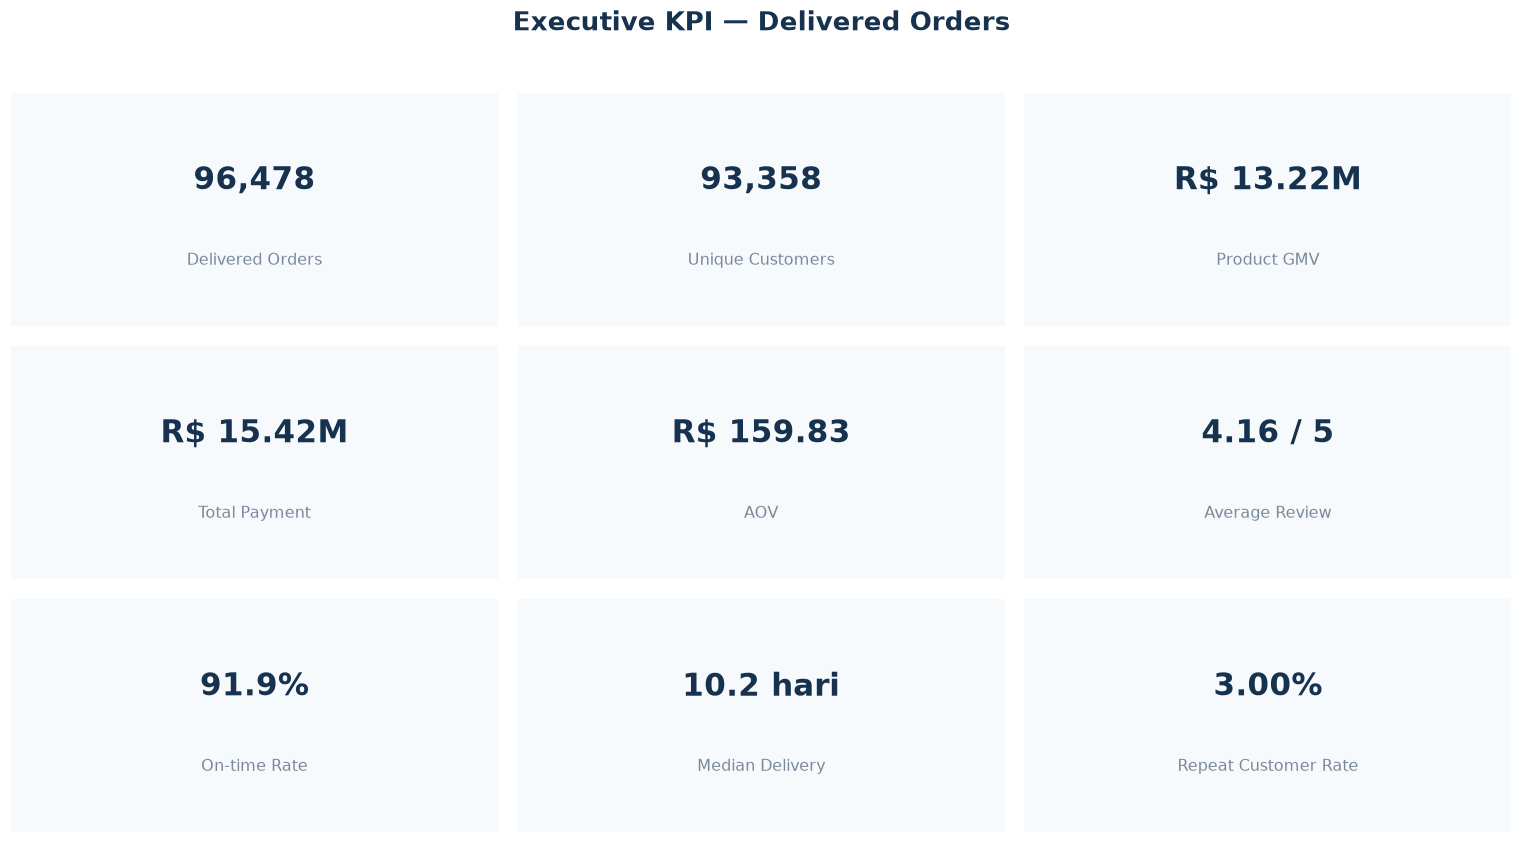

In [8]:
customer_frequency = delivered.groupby("customer_unique_id")["order_id"].nunique()
repeat_customer_rate = customer_frequency.ge(2).mean()

kpis = {
    "Delivered Orders": len(delivered),
    "Unique Customers": delivered["customer_unique_id"].nunique(),
    "Product GMV": delivered["product_gmv"].sum(),
    "Total Payment": delivered["payment_value"].sum(),
    "AOV": delivered["order_value"].mean(),
    "Average Review": delivered["review_score"].mean(),
    "On-time Rate": delivered["on_time"].mean(),
    "Median Delivery": delivered["delivery_days"].median(),
    "Repeat Customer Rate": repeat_customer_rate,
}

labels = list(kpis)
values = [
    f"{kpis['Delivered Orders']:,.0f}",
    f"{kpis['Unique Customers']:,.0f}",
    format_brl(kpis["Product GMV"]),
    format_brl(kpis["Total Payment"]),
    format_brl(kpis["AOV"]),
    f"{kpis['Average Review']:.2f} / 5",
    pct(kpis["On-time Rate"]),
    f"{kpis['Median Delivery']:.1f} hari",
    pct(kpis["Repeat Customer Rate"], 2),
]

fig, axes = plt.subplots(3, 3, figsize=(14, 7.5))
for ax, label, value in zip(axes.flat, labels, values):
    ax.set_facecolor("#F7FAFC")
    ax.text(0.5, 0.62, value, ha="center", va="center", fontsize=20, fontweight="bold", color=NAVY)
    ax.text(0.5, 0.28, label, ha="center", va="center", fontsize=10.5, color=GREY)
    ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)
fig.suptitle("Executive KPI — Delivered Orders", fontsize=17, fontweight="bold", color=NAVY, y=1.02)
plt.tight_layout()
plt.show()

**Interpretasi:**

Dataset mencakup 96.478 delivered orders dari 93.358 unique customers. Product GMV mencapai R$13,22 juta dan total payment R$15,42 juta, sedangkan AOV berbasis harga produk + freight adalah R$159,83. Rating rata-rata 4,16/5 dan on-time rate 91,9% tergolong baik, tetapi repeat-customer rate hanya 3,00%, sehingga retensi menjadi peluang perbaikan utama.

# **4. Pertumbuhan dan Tren Waktu**

**Tujuan:** Membandingkan perkembangan volume order serta GMV pada bulan yang memiliki periode observasi penuh.

**Tindakan yang dilakukan:**

1. Membatasi analisis pada Januari 2017–Agustus 2018 untuk menghindari bulan awal/akhir yang parsial.
2. Mengagregasi orders, customers, GMV, order value, average review, dan on-time rate per bulan.
3. Membuat grafik delivered orders dan product GMV.
4. Menghitung pertumbuhan Januari–Agustus 2018 terhadap periode sama 2017 serta mencari bulan puncak.

**Alasan:** Perbandingan periode penuh menghindari kesimpulan palsu akibat jumlah hari observasi yang tidak sama.



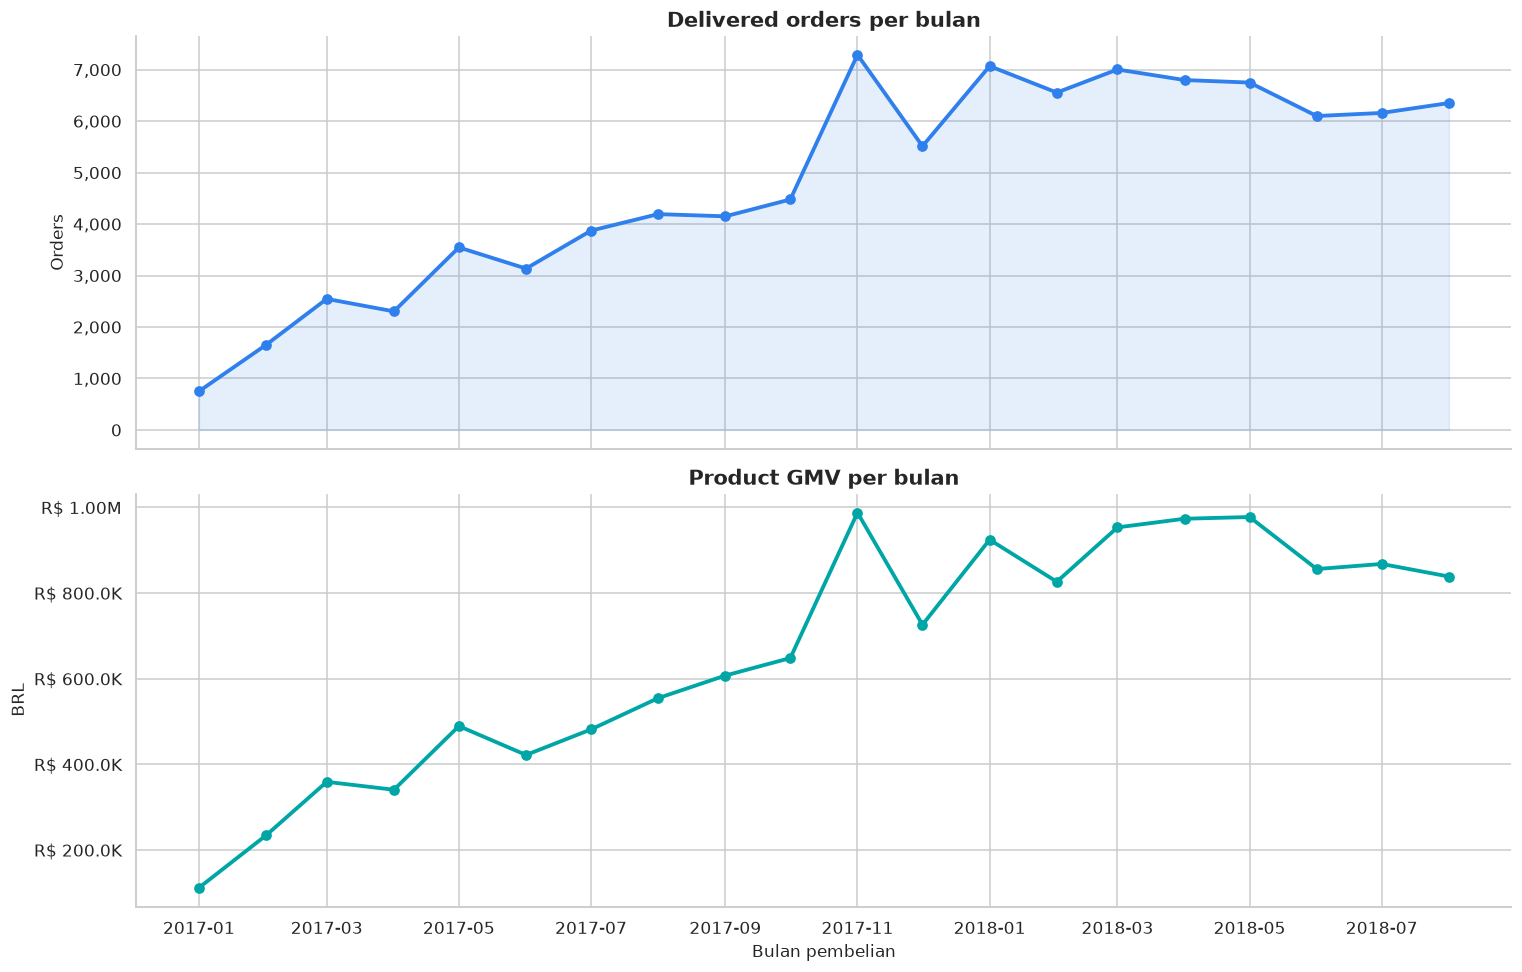

**Insight:** Januari–Agustus 2018 mencatat pertumbuhan **139.9% pada jumlah order** dan **141.1% pada GMV** dibanding periode sama 2017. Puncak volume terjadi pada **November 2017** dengan **7,289 delivered orders**.

In [9]:
# 2017-01 s.d. 2018-08 adalah rentang bulan penuh yang dapat dibandingkan.
complete_period = delivered.loc[
    delivered["order_purchase_timestamp"].between("2017-01-01", "2018-08-31 23:59:59")
].copy()

monthly = (
    complete_period.groupby("purchase_month", as_index=False)
    .agg(
        orders=("order_id", "nunique"),
        customers=("customer_unique_id", "nunique"),
        gmv=("product_gmv", "sum"),
        order_value=("order_value", "sum"),
        avg_review=("review_score", "mean"),
        on_time_rate=("on_time", "mean"),
    )
)
monthly["aov"] = monthly["order_value"] / monthly["orders"]

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)
axes[0].plot(monthly["purchase_month"], monthly["orders"], marker="o", color=BLUE, linewidth=2.5)
axes[0].fill_between(monthly["purchase_month"], monthly["orders"], alpha=0.12, color=BLUE)
axes[0].set_title("Delivered orders per bulan")
axes[0].set_ylabel("Orders")
axes[0].yaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))

axes[1].plot(monthly["purchase_month"], monthly["gmv"], marker="o", color=TEAL, linewidth=2.5, label="Product GMV")
axes[1].set_title("Product GMV per bulan")
axes[1].set_ylabel("BRL")
axes[1].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: format_brl(x)))
axes[1].set_xlabel("Bulan pembelian")
plt.tight_layout()
plt.show()

jan_aug = complete_period.loc[complete_period["order_purchase_timestamp"].dt.month.le(8)]
yoy = jan_aug.groupby("purchase_year").agg(orders=("order_id", "nunique"), gmv=("product_gmv", "sum"))
order_yoy = yoy.loc[2018, "orders"] / yoy.loc[2017, "orders"] - 1
gmv_yoy = yoy.loc[2018, "gmv"] / yoy.loc[2017, "gmv"] - 1
peak_month = monthly.loc[monthly["orders"].idxmax()]

display(Markdown(
    f"**Insight:** Januari–Agustus 2018 mencatat pertumbuhan **{order_yoy:.1%} pada jumlah order** "
    f"dan **{gmv_yoy:.1%} pada GMV** dibanding periode sama 2017. Puncak volume terjadi pada "
    f"**{peak_month['purchase_month']:%B %Y}** dengan **{peak_month['orders']:,.0f} delivered orders**."
))

**Interpretasi output Cell Kode 09:**

Januari–Agustus 2018 tumbuh 139,9% dalam jumlah order dan 141,1% dalam GMV dibanding periode yang sama pada 2017. Puncak volume terdapat pada November 2017 dengan 7.289 delivered orders. Lonjakan tersebut layak dianalisis lebih lanjut bersama kalender promosi, tetapi notebook tidak langsung menganggap promosi sebagai penyebab karena variabel kampanye tidak tersedia.

# **5. Performa Kategori Produk**



**Tujuan:** Membedakan kategori pemimpin volume dari kategori pemimpin nilai penjualan.

**Tindakan yang dilakukan:**

1. Mengagregasi unit, order unik, GMV, average price, freight, dan jumlah seller per kategori.
2. Menghitung GMV share serta freight-to-GMV ratio.
3. Menampilkan top 10 kategori berdasarkan unit dan GMV dalam dua grafik.
4. Menghitung kontribusi top 10 kategori serta menampilkan kategori dengan volume terendah.

**Alasan:** Kategori dengan banyak unit belum tentu memberi GMV terbesar karena perbedaan harga rata-rata.



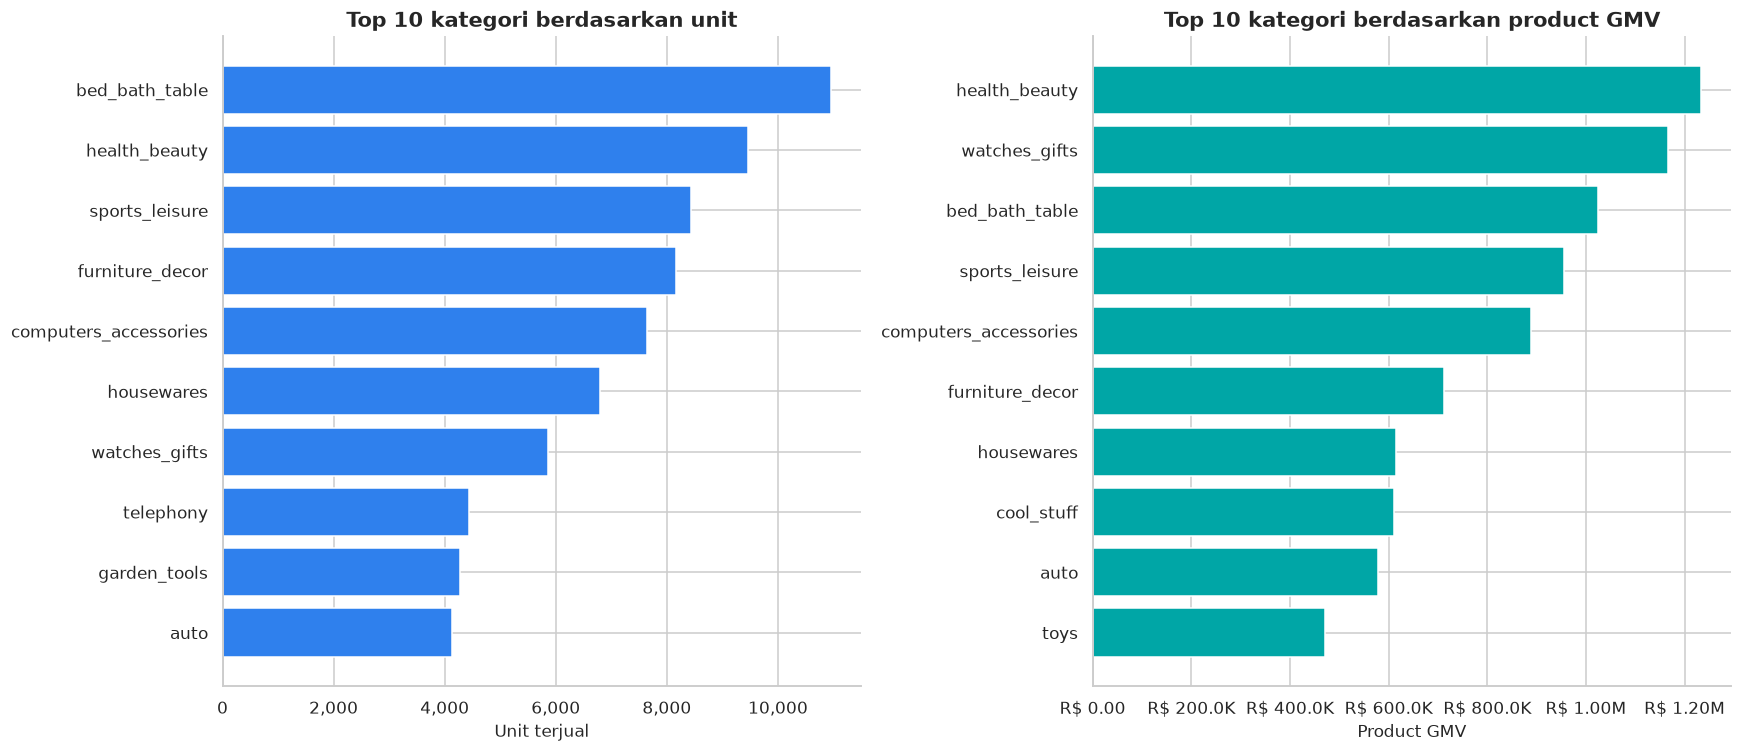

**Insight:** `bed_bath_table` memimpin volume dengan **10,953 unit**, sedangkan `health_beauty` memimpin GMV sebesar **R$ 1.23M**. Top 10 kategori menyumbang **62.4%** dari total product GMV—volume dan nilai perlu dikelola sebagai dua sasaran berbeda.

**Kategori dengan volume terendah (interpretasikan hati-hati karena basis sangat kecil):**

,category,units,orders,gmv
63,security_and_services,2,2,R$ 283.29
29,fashion_childrens_clothes,7,7,R$ 519.95
59,pc_gamer,8,7,R$ 1.3K
11,cds_dvds_musicals,14,12,R$ 730.00
52,la_cuisine,14,13,R$ 2.1K
62,portateis_cozinha_e_preparadores_de_alimentos,14,13,R$ 3.9K
3,arts_and_craftmanship,24,23,R$ 1.8K
32,fashion_sport,29,26,R$ 2.1K


In [10]:
category_perf = (
    delivered_items.groupby("category", as_index=False)
    .agg(
        units=("order_item_id", "size"),
        orders=("order_id", "nunique"),
        gmv=("price", "sum"),
        avg_price=("price", "mean"),
        freight=("freight_value", "sum"),
        sellers=("seller_id", "nunique"),
    )
)
category_perf["gmv_share"] = category_perf["gmv"] / category_perf["gmv"].sum()
category_perf["freight_to_gmv"] = category_perf["freight"] / category_perf["gmv"]

top_units = category_perf.nlargest(10, "units").sort_values("units")
top_gmv = category_perf.nlargest(10, "gmv").sort_values("gmv")

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
axes[0].barh(top_units["category"], top_units["units"], color=BLUE)
axes[0].set_title("Top 10 kategori berdasarkan unit")
axes[0].set_xlabel("Unit terjual")
axes[0].xaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))

axes[1].barh(top_gmv["category"], top_gmv["gmv"], color=TEAL)
axes[1].set_title("Top 10 kategori berdasarkan product GMV")
axes[1].set_xlabel("Product GMV")
axes[1].xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: format_brl(x)))
plt.tight_layout()
plt.show()

top_unit_category = category_perf.loc[category_perf["units"].idxmax()]
top_gmv_category = category_perf.loc[category_perf["gmv"].idxmax()]
top10_gmv_share = category_perf.nlargest(10, "gmv")["gmv"].sum() / category_perf["gmv"].sum()

display(Markdown(
    f"**Insight:** `{top_unit_category['category']}` memimpin volume dengan **{top_unit_category['units']:,.0f} unit**, "
    f"sedangkan `{top_gmv_category['category']}` memimpin GMV sebesar **{format_brl(top_gmv_category['gmv'])}**. "
    f"Top 10 kategori menyumbang **{top10_gmv_share:.1%}** dari total product GMV—volume dan nilai perlu dikelola sebagai dua sasaran berbeda."
))

tail_categories = category_perf.nsmallest(8, "units")[["category", "units", "orders", "gmv"]].copy()
tail_categories["gmv"] = tail_categories["gmv"].map(format_brl)
display(Markdown("**Kategori dengan volume terendah (interpretasikan hati-hati karena basis sangat kecil):**"))
display(tail_categories)

**Interpretasi output Cell Kode 10:**

`bed_bath_table` memimpin volume dengan 10.953 unit, sedangkan `health_beauty` memimpin GMV sekitar R$1,23 juta. Top 10 kategori menghasilkan 62,4% product GMV. Kategori ber-volume sangat rendah tidak otomatis harus dihentikan; evaluasi tetap membutuhkan margin, biaya penyimpanan, dan peran kategori dalam kelengkapan katalog.

# **6. Delivery Experience & Kepuasan Pelanggan**

## **6.1 Menguji Hubungan Delivery Experience dan rating**

**Tujuan:** Mengukur perbedaan pola kepuasan antara on-time dan late orders.

**Tindakan yang dilakukan:**

1. Memilih delivered orders yang memiliki review, status on-time, dan delivery days.
2. Menghitung jumlah order, average review, low-rating rate, dan median delivery per status.
3. Menjalankan Mann-Whitney U test serta korelasi Spearman.
4. Membentuk kelompok durasi pengiriman dan komposisi rating.
5. Membuat stacked bar rating serta grafik average review berdasarkan durasi.

**Alasan:** Rating berskala ordinal dan distribusinya tidak normal, sehingga metode nonparametrik lebih sesuai daripada hanya membandingkan mean.


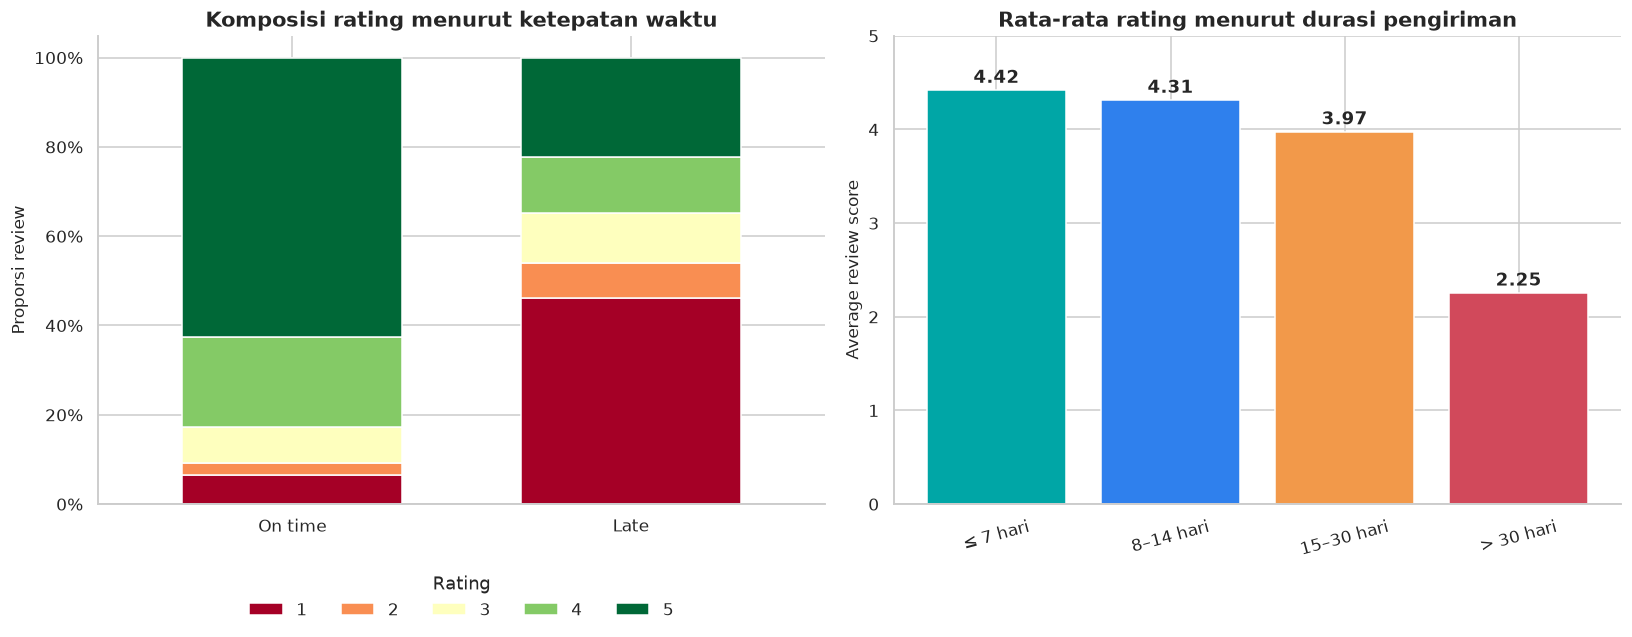

,orders,avg_review,low_rating_rate,median_delivery_days
delivery_status,,,,
On time,"88,163",4.29,9.2%,9.7
Late,"7,661",2.57,54.0%,29.1


In [11]:
review_delivery = delivered.dropna(subset=["review_score", "on_time", "delivery_days"]).copy()
review_delivery["delivery_status"] = np.where(review_delivery["on_time"].eq(True), "On time", "Late")

delivery_review_summary = (
    review_delivery.groupby("delivery_status", observed=True)
    .agg(
        orders=("order_id", "size"),
        avg_review=("review_score", "mean"),
        low_rating_rate=("review_score", lambda x: x.le(2).mean()),
        median_delivery_days=("delivery_days", "median"),
    )
    .reindex(["On time", "Late"])
)

on_time_scores = review_delivery.loc[review_delivery["on_time"].eq(True), "review_score"]
late_scores = review_delivery.loc[review_delivery["on_time"].eq(False), "review_score"]
mw_stat, mw_pvalue = mannwhitneyu(on_time_scores, late_scores, alternative="two-sided")
rho, spearman_pvalue = spearmanr(review_delivery["delivery_days"], review_delivery["review_score"], nan_policy="omit")

review_delivery["delivery_band"] = pd.cut(
    review_delivery["delivery_days"],
    bins=[-np.inf, 7, 14, 30, np.inf],
    labels=["≤ 7 hari", "8–14 hari", "15–30 hari", "> 30 hari"],
)
delivery_band = (
    review_delivery.groupby("delivery_band", observed=False)
    .agg(avg_review=("review_score", "mean"), orders=("order_id", "size"))
    .reset_index()
)

rating_mix = pd.crosstab(
    review_delivery["review_score"], review_delivery["delivery_status"], normalize="columns"
).reindex(index=[1, 2, 3, 4, 5], columns=["On time", "Late"]).fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
rating_mix.T.plot(kind="bar", stacked=True, colormap="RdYlGn", ax=axes[0], width=0.65)
axes[0].set_title("Komposisi rating menurut ketepatan waktu")
axes[0].set_xlabel("")
axes[0].set_ylabel("Proporsi review")
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[0].tick_params(axis="x", rotation=0)
axes[0].legend(title="Rating", ncol=5, loc="upper center", bbox_to_anchor=(0.5, -0.12))

axes[1].bar(delivery_band["delivery_band"].astype(str), delivery_band["avg_review"], color=[TEAL, BLUE, ORANGE, RED])
axes[1].set_title("Rata-rata rating menurut durasi pengiriman")
axes[1].set_ylabel("Average review score")
axes[1].set_ylim(0, 5)
axes[1].tick_params(axis="x", rotation=15)
for i, value in enumerate(delivery_band["avg_review"]):
    axes[1].text(i, value + 0.08, f"{value:.2f}", ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

display(format_table(delivery_review_summary, {
    "orders": "{:,.0f}", "avg_review": "{:.2f}",
    "low_rating_rate": "{:.1%}", "median_delivery_days": "{:.1f}",
}))

**Interpretasi:**

On-time orders memiliki rating rata-rata 4,29 dan low-rating rate 9,2%, sedangkan late orders memiliki rating 2,57 dan low-rating rate 54,0%. Median durasi late order mencapai 29,1 hari dibanding 9,7 hari untuk on-time order. Pola grafik juga menunjukkan rating menurun saat durasi pengiriman bertambah.

## **6.2 Menerjemahkan Hasil Statistik Menjadi Insight Bisnis**

**Tujuan:** Mengubah hasil uji statistik sebelumnya menjadi ukuran efek yang mudah dipahami pengambil keputusan.

**Tindakan yang dilakukan:**

1. Menghitung perbandingan low-rating rate late terhadap on-time.
2. Menghitung selisih average review kedua kelompok.
3. Menampilkan p-value Mann–Whitney dan koefisien korelasi Spearman dalam narasi.

**Alasan:** P-value saja tidak menjelaskan besarnya masalah; rasio risiko dan selisih rating lebih mudah ditindaklanjuti.



In [12]:
late_low = delivery_review_summary.loc["Late", "low_rating_rate"]
ontime_low = delivery_review_summary.loc["On time", "low_rating_rate"]
low_rating_multiplier = late_low / ontime_low
rating_gap = delivery_review_summary.loc["On time", "avg_review"] - delivery_review_summary.loc["Late", "avg_review"]

display(Markdown(
    f"**Insight:** late orders memiliki low-rating rate **{late_low:.1%}**, dibanding **{ontime_low:.1%}** pada on-time orders "
    f"(**{low_rating_multiplier:.1f}× lebih tinggi**). Rata-rata rating berbeda **{rating_gap:.2f} poin**. "
    f"Mann–Whitney `p < 0.001` ({mw_pvalue:.2e}); korelasi Spearman antara delivery days dan rating adalah "
    f"**ρ = {rho:.3f}** (`p={spearman_pvalue:.2e}`). Ini menunjukkan asosiasi yang konsisten secara statistik, tetapi bukan bukti kausalitas."
))

**Insight:** late orders memiliki low-rating rate **54.0%**, dibanding **9.2%** pada on-time orders (**5.9× lebih tinggi**). Rata-rata rating berbeda **1.73 poin**. Mann–Whitney `p < 0.001` (0.00e+00); korelasi Spearman antara delivery days dan rating adalah **ρ = -0.235** (`p=0.00e+00`). Ini menunjukkan asosiasi yang konsisten secara statistik, tetapi bukan bukti kausalitas.

**Interpretasi:**

Low-rating rate pada late orders sekitar 5,9 kali on-time orders dan average rating berbeda 1,73 poin. P-value yang sangat kecil menunjukkan perbedaan konsisten secara statistik, sedangkan Spearman ρ = −0,235 menunjukkan hubungan negatif lemah–moderat antara lamanya pengiriman dan rating. Hasil ini tetap bersifat asosiasi, bukan bukti bahwa keterlambatan adalah satu-satunya penyebab rating rendah.

# **7. Wilayah Pelanggan dan Risiko Layanan**


**Tujuan:** Menentukan wilayah dengan volume terbesar dan wilayah yang perlu diprioritaskan dalam perbaikan delivery.

**Tindakan yang dilakukan:**

1. Mengagregasi orders, customers, GMV, review, delivery days, dan on-time rate per customer state.
2. Menggabungkan jumlah customer records per prefix kode pos dengan koordinat median yang telah divalidasi pada tahap cleaning.
3. Membuat ranking state dan scatter plot sebaran customer.
4. Menyusun daftar state dengan minimal 1.000 order dan on-time rate terendah.

**Alasan:** Prioritas operasional harus mempertimbangkan volume dan kualitas layanan sekaligus, bukan hanya melihat jumlah pelanggan.


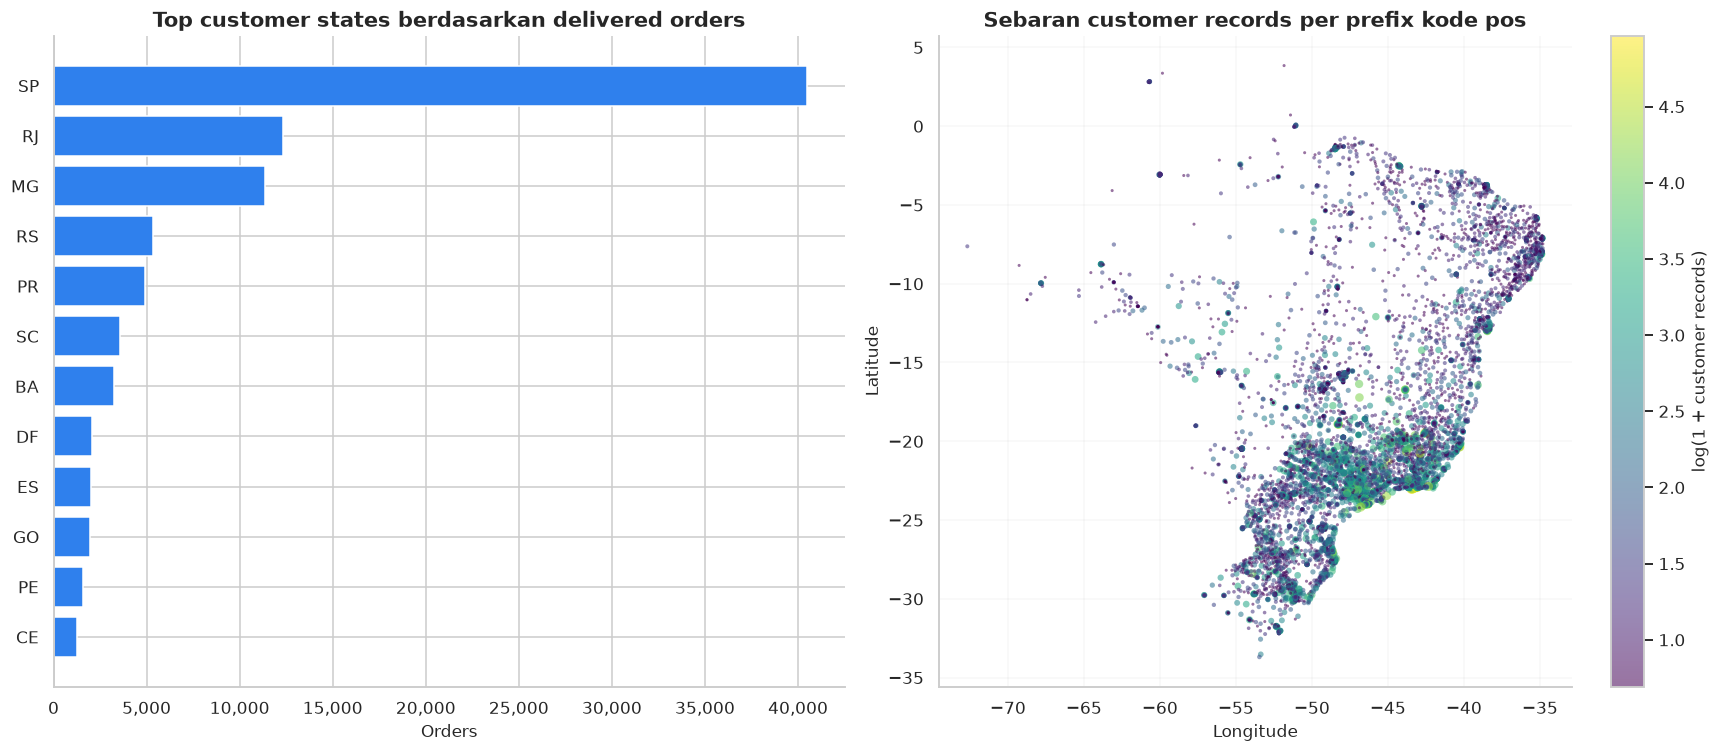

**Insight:** `SP` menyumbang **42.0%** dari delivered orders. Tabel berikut memprioritaskan state ber-volume ≥1.000 order dengan on-time rate terendah.

,customer_state,orders,on_time_rate,median_delivery_days,avg_review
5,CE,"1,279",84.7%,18.2,3.94
4,BA,"3,256",86.0%,16.9,3.93
18,RJ,"12,350",86.5%,12.0,3.97
7,ES,"1,995",87.8%,13.6,4.08
15,PE,"1,593",89.2%,15.7,4.08
23,SC,"3,546",90.2%,13.0,4.13
8,GO,"1,957",91.8%,13.9,4.10
22,RS,"5,345",92.9%,13.2,4.19


In [13]:
state_perf = (
    delivered.groupby("customer_state", as_index=False)
    .agg(
        orders=("order_id", "nunique"),
        customers=("customer_unique_id", "nunique"),
        gmv=("product_gmv", "sum"),
        avg_review=("review_score", "mean"),
        median_delivery_days=("delivery_days", "median"),
        on_time_rate=("on_time", "mean"),
    )
)
state_perf["order_share"] = state_perf["orders"] / state_perf["orders"].sum()

customer_zip_counts = (
    customers.groupby("customer_zip_code_prefix", as_index=False)
    .agg(customer_records=("customer_id", "size"))
)
customer_geo = customer_zip_counts.merge(
    geo_zip, left_on="customer_zip_code_prefix", right_on="geolocation_zip_code_prefix", how="inner"
)
top_states = state_perf.nlargest(12, "orders").sort_values("orders")
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
axes[0].barh(top_states["customer_state"], top_states["orders"], color=BLUE)
axes[0].set_title("Top customer states berdasarkan delivered orders")
axes[0].set_xlabel("Orders")
axes[0].xaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))

scatter = axes[1].scatter(
    customer_geo["geolocation_lng"], customer_geo["geolocation_lat"],
    s=np.clip(np.sqrt(customer_geo["customer_records"]) * 4, 3, 45),
    c=np.log1p(customer_geo["customer_records"]), cmap="viridis", alpha=0.55, linewidths=0,
)
axes[1].set_title("Sebaran customer records per prefix kode pos")
axes[1].set_xlabel("Longitude"); axes[1].set_ylabel("Latitude")
axes[1].grid(alpha=0.15)
plt.colorbar(scatter, ax=axes[1], label="log(1 + customer records)")
plt.tight_layout()
plt.show()

largest_state = state_perf.loc[state_perf["orders"].idxmax()]
service_risk_states = (
    state_perf.loc[state_perf["orders"].ge(1_000)]
    .nsmallest(8, "on_time_rate")
    [["customer_state", "orders", "on_time_rate", "median_delivery_days", "avg_review"]]
)
display(Markdown(
    f"**Insight:** `{largest_state['customer_state']}` menyumbang **{largest_state['order_share']:.1%}** dari delivered orders. "
    "Tabel berikut memprioritaskan state ber-volume ≥1.000 order dengan on-time rate terendah."
))
display(format_table(service_risk_states, {
    "orders": "{:,.0f}", "on_time_rate": "{:.1%}",
    "median_delivery_days": "{:.1f}", "avg_review": "{:.2f}",
}))

**Interpretasi:**

São Paulo (SP) menyumbang sekitar 42,0% delivered orders dan menjadi wilayah dengan leverage terbesar. Di antara state ber-volume minimal 1.000 order, CE, BA, dan RJ memiliki on-time rate terendah. Temuan ini dapat digunakan untuk menentukan urutan audit jalur logistik tanpa mengabaikan jumlah order yang terdampak.

# **8. Customer Value: RFM Segmentation dan Cohort Retention**

## **8.1 Membangun Segmentasi RFM Berbasis Aturan Bisnis**

**Tujuan:** Mengelompokkan customer berdasarkan kebaruan transaksi, frekuensi, dan nilai pembayaran.

**Tindakan yang dilakukan:**

1. Menentukan reference date satu hari setelah transaksi delivered terakhir.
2. Menghitung recency, frequency, dan monetary berbasis total payment pada level `customer_unique_id`.
3. Membentuk threshold kuartil recency dan monetary.
4. Menerapkan aturan segmentasi Champions, repeat segments, serta one-time segments.
5. Menghitung ukuran segmen dan kontribusi revenue lalu membandingkannya dalam grafik.

**Alasan:** Sebagian besar customer hanya bertransaksi sekali, sehingga aturan bisnis lebih mudah dijelaskan daripada memaksakan pembagian kuantil frequency yang memiliki banyak nilai sama.


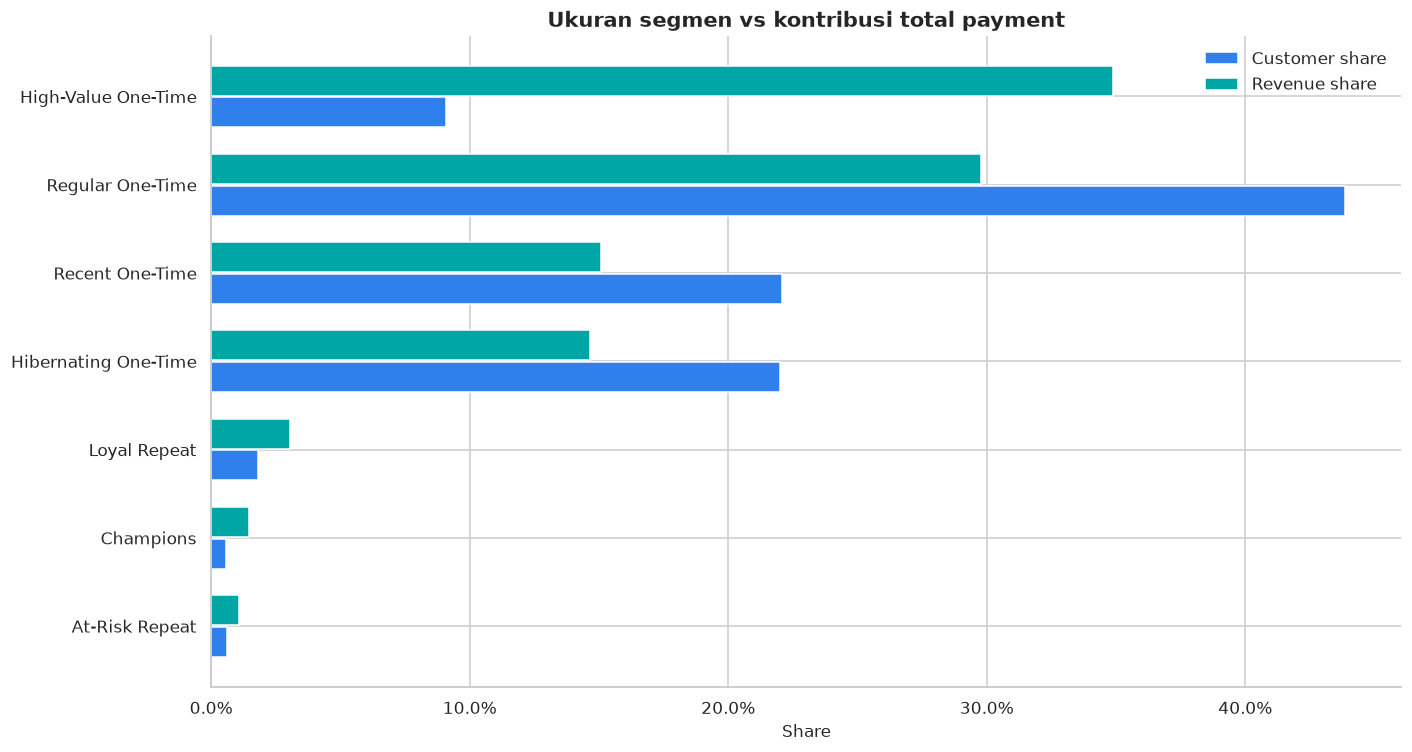

,segment,customers,revenue,avg_frequency,avg_monetary,median_recency,customer_share,revenue_share
3,High-Value One-Time,"8,466",R$ 5.38M,1.00,R$ 635.55,219,9.1%,34.9%
6,Regular One-Time,"40,936",R$ 4.59M,1.00,R$ 112.24,220,43.8%,29.8%
5,Recent One-Time,"20,614",R$ 2.32M,1.00,R$ 112.71,57,22.1%,15.1%
2,Hibernating One-Time,"20,541",R$ 2.26M,1.00,R$ 109.99,445,22.0%,14.6%
4,Loyal Repeat,"1,700",R$ 470.3K,2.09,R$ 276.67,197,1.8%,3.0%
1,Champions,524,R$ 226.5K,2.22,R$ 432.18,60,0.6%,1.5%
0,At-Risk Repeat,577,R$ 167.6K,2.08,R$ 290.40,430,0.6%,1.1%


In [14]:
reference_date = delivered["order_purchase_timestamp"].max().normalize() + pd.Timedelta(days=1)
rfm = (
    delivered.groupby("customer_unique_id", as_index=False)
    .agg(
        last_purchase=("order_purchase_timestamp", "max"),
        first_purchase=("order_purchase_timestamp", "min"),
        frequency=("order_id", "nunique"),
        monetary=("payment_value", "sum"),
    )
)
rfm["recency"] = (reference_date - rfm["last_purchase"].dt.normalize()).dt.days

r25, r75 = rfm["recency"].quantile([0.25, 0.75])
m75, m90 = rfm["monetary"].quantile([0.75, 0.90])

conditions = [
    rfm["frequency"].ge(2) & rfm["recency"].le(r25) & rfm["monetary"].ge(m75),
    rfm["frequency"].ge(2) & rfm["recency"].gt(r75),
    rfm["frequency"].ge(2),
    rfm["frequency"].eq(1) & rfm["monetary"].ge(m90),
    rfm["frequency"].eq(1) & rfm["recency"].le(r25),
    rfm["frequency"].eq(1) & rfm["recency"].gt(r75),
]
labels = [
    "Champions", "At-Risk Repeat", "Loyal Repeat",
    "High-Value One-Time", "Recent One-Time", "Hibernating One-Time",
]
rfm["segment"] = np.select(conditions, labels, default="Regular One-Time")

segment_summary = (
    rfm.groupby("segment", as_index=False)
    .agg(
        customers=("customer_unique_id", "nunique"),
        revenue=("monetary", "sum"),
        avg_frequency=("frequency", "mean"),
        avg_monetary=("monetary", "mean"),
        median_recency=("recency", "median"),
    )
)
segment_summary["customer_share"] = segment_summary["customers"] / segment_summary["customers"].sum()
segment_summary["revenue_share"] = segment_summary["revenue"] / segment_summary["revenue"].sum()
segment_summary = segment_summary.sort_values("revenue", ascending=False)

plot_segments = segment_summary.sort_values("revenue_share")
y = np.arange(len(plot_segments))
fig, ax = plt.subplots(figsize=(13, 7))
ax.barh(y - 0.18, plot_segments["customer_share"], height=0.34, label="Customer share", color=BLUE)
ax.barh(y + 0.18, plot_segments["revenue_share"], height=0.34, label="Revenue share", color=TEAL)
ax.set_yticks(y, plot_segments["segment"])
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_title("Ukuran segmen vs kontribusi total payment")
ax.set_xlabel("Share")
ax.legend()
plt.tight_layout()
plt.show()

display(format_table(segment_summary, {
    "customers": "{:,.0f}", "revenue": lambda x: format_brl(x),
    "avg_frequency": "{:.2f}", "avg_monetary": lambda x: format_brl(x),
    "median_recency": "{:.0f}", "customer_share": "{:.1%}", "revenue_share": "{:.1%}",
}))

**Interpretasi:**

Segmen `High-Value One-Time` hanya mencakup 9,1% customer tetapi menyumbang 34,9% total payment. Champions dan repeat segments berukuran kecil, sejalan dengan repeat rate 3,0%. Karena aturan ini bersifat heuristik, threshold sebaiknya dikalibrasi kembali ketika data terbaru atau biaya kampanye tersedia.

## **8.2 Menghitung Monthly Cohort Retention**

**Tujuan:** Mengukur berapa banyak customer kembali bertransaksi setelah bulan pembelian pertama.

**Tindakan yang dilakukan:**

1. Menentukan order month dan acquisition month setiap customer.
2. Menghitung selisih bulan sebagai `cohort_index`.
3. Membuat matriks customer unik dan retention rate untuk bulan 0–6.
4. Membatasi heatmap pada kohort yang mempunyai kesempatan observasi enam bulan.
5. Menghitung weighted retention bulan ke-1 dan ke-3.

**Alasan:** Cohort analysis membedakan pertumbuhan akuisisi dari kemampuan mempertahankan customer.



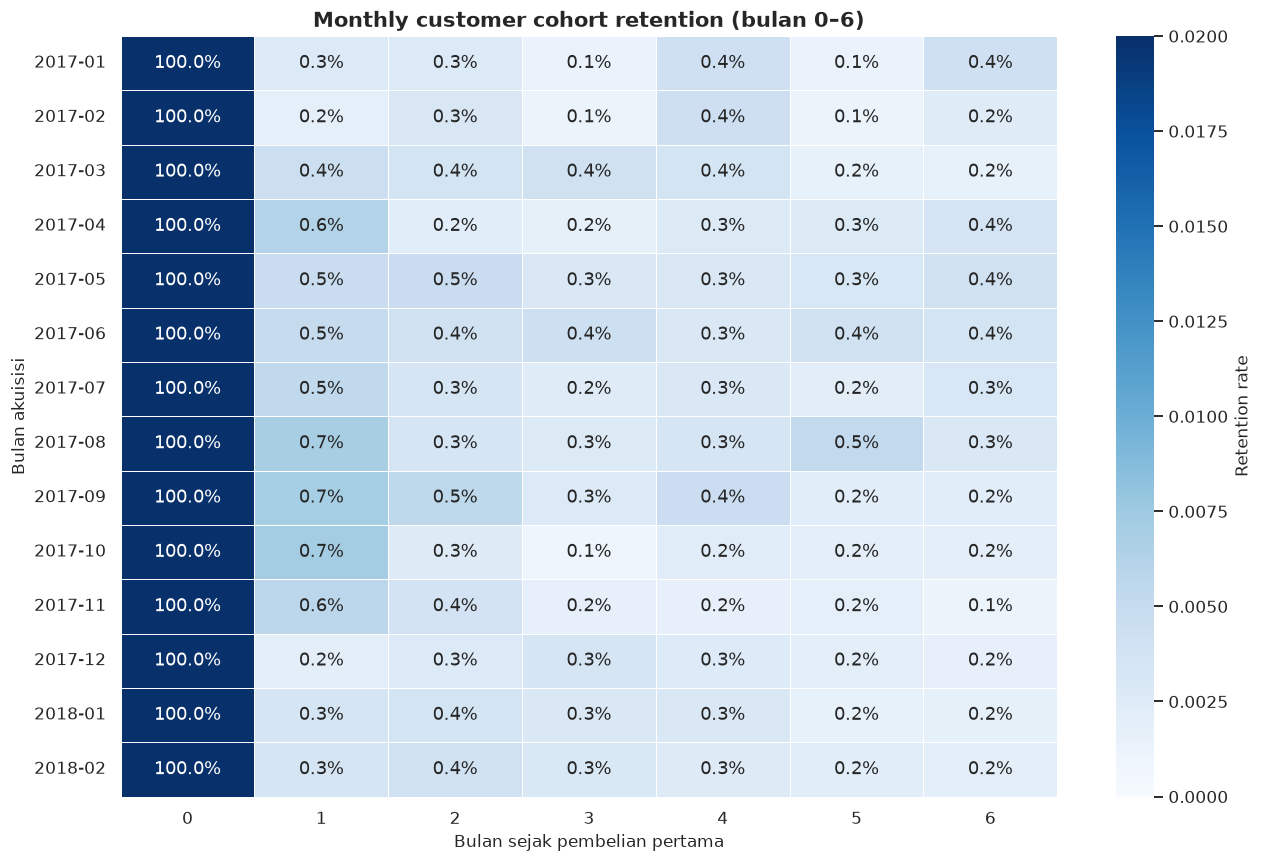

**Insight:** hanya **3.00%** customer yang memiliki ≥2 delivered orders. Weighted retention bulan ke-1 sekitar **0.48%** dan bulan ke-3 **0.25%**. Segmen dengan kontribusi payment terbesar adalah **High-Value One-Time** (**34.9%** dari total), sehingga prioritas utama adalah mengubah one-time buyer bernilai tinggi menjadi repeat buyer.

In [15]:
cohort_base = delivered[["customer_unique_id", "order_id", "order_purchase_timestamp"]].copy()
cohort_base["order_month"] = cohort_base["order_purchase_timestamp"].dt.to_period("M").dt.to_timestamp()
acquisition = cohort_base.groupby("customer_unique_id", as_index=False)["order_month"].min().rename(
    columns={"order_month": "cohort_month"}
)
cohort_base = cohort_base.merge(acquisition, on="customer_unique_id", validate="many_to_one")
cohort_base["cohort_index"] = (
    (cohort_base["order_month"].dt.year - cohort_base["cohort_month"].dt.year) * 12
    + cohort_base["order_month"].dt.month - cohort_base["cohort_month"].dt.month
)

cohort_counts = (
    cohort_base.groupby(["cohort_month", "cohort_index"])["customer_unique_id"]
    .nunique().unstack(fill_value=0)
)
retention = cohort_counts.div(cohort_counts[0], axis=0)

# Kohort ini semuanya memiliki kesempatan observasi minimal enam bulan.
cohort_view = retention.loc["2017-01-01":"2018-02-01", 0:6]
fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(
    cohort_view, annot=True, fmt=".1%", cmap="Blues", vmin=0, vmax=0.02,
    linewidths=0.4, cbar_kws={"label": "Retention rate"}, ax=ax,
)
ax.set_title("Monthly customer cohort retention (bulan 0–6)")
ax.set_xlabel("Bulan sejak pembelian pertama")
ax.set_ylabel("Bulan akuisisi")
ax.set_yticklabels([timestamp.strftime("%Y-%m") for timestamp in cohort_view.index], rotation=0)
plt.tight_layout()
plt.show()

eligible_m1 = cohort_counts.index <= (cohort_counts.index.max() - pd.DateOffset(months=1))
eligible_m3 = cohort_counts.index <= (cohort_counts.index.max() - pd.DateOffset(months=3))
month1_retention = cohort_counts.loc[eligible_m1, 1].sum() / cohort_counts.loc[eligible_m1, 0].sum()
month3_retention = cohort_counts.loc[eligible_m3, 3].sum() / cohort_counts.loc[eligible_m3, 0].sum()

best_segment = segment_summary.iloc[0]
display(Markdown(
    f"**Insight:** hanya **{repeat_customer_rate:.2%}** customer yang memiliki ≥2 delivered orders. "
    f"Weighted retention bulan ke-1 sekitar **{month1_retention:.2%}** dan bulan ke-3 **{month3_retention:.2%}**. "
    f"Segmen dengan kontribusi payment terbesar adalah **{best_segment['segment']}** "
    f"(**{best_segment['revenue_share']:.1%}** dari total), sehingga prioritas utama adalah mengubah one-time buyer bernilai tinggi menjadi repeat buyer."
))

**Interpretasi:**

Retention bulan ke-1 hanya sekitar 0,48% dan bulan ke-3 sekitar 0,25%. Nilai bulan 0 selalu 100% karena merupakan bulan akuisisi. Retention sesudahnya yang sangat rendah memperkuat kebutuhan program second-purchase, khususnya untuk customer one-time bernilai tinggi.

# **9. Payment Mix dan Konsentrasi Seller**

## 9.1 Menganalisis Metode Pembayaran dan Cicilan

**Tujuan:** Memahami kontribusi setiap payment method serta pola AOV berdasarkan jumlah cicilan.

**Tindakan yang dilakukan:**

1. Menghubungkan payment records dengan status order dan memilih delivered orders.
2. Mengagregasi jumlah record serta payment value per metode.
3. Mengelompokkan maksimum cicilan menjadi lima band.
4. Menghitung jumlah order dan AOV berbasis order value per installment band.
5. Membuat grafik payment share dan AOV cicilan.

**Alasan:** Payment method membantu memahami preferensi transaksi, sedangkan installment band dapat mengindikasikan akses terhadap pembelian bernilai lebih besar. Definisi AOV tetap sama dengan dashboard: harga produk + freight per order.


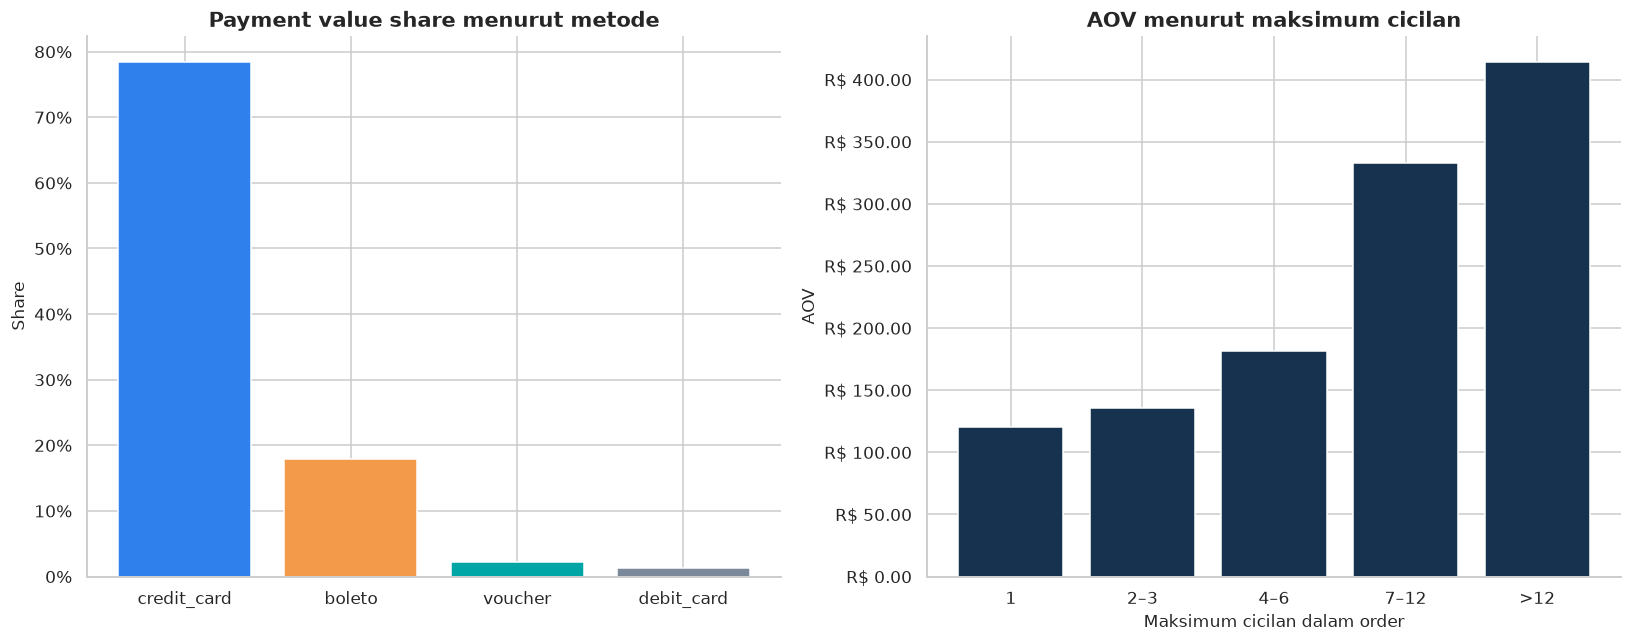

,payment_type,records,payment_value,value_share
1,credit_card,"74,586",R$ 12.10M,78.5%
0,boleto,"19,191",R$ 2.77M,18.0%
3,voucher,"5,493",R$ 343.0K,2.2%
2,debit_card,"1,486",R$ 208.4K,1.4%


In [16]:
delivered_payment_rows = payments.merge(
    order_fact[["order_id", "order_status"]], on="order_id", how="left", validate="many_to_one"
).query("order_status == 'delivered'")

payment_mix = (
    delivered_payment_rows.groupby("payment_type", as_index=False)
    .agg(records=("order_id", "size"), payment_value=("payment_value", "sum"))
    .sort_values("payment_value", ascending=False)
)
payment_mix["value_share"] = payment_mix["payment_value"] / payment_mix["payment_value"].sum()

installment_order = delivered.dropna(subset=["max_installments", "order_value"]).copy()
installment_order["installment_band"] = pd.cut(
    installment_order["max_installments"],
    bins=[-0.1, 1, 3, 6, 12, np.inf],
    labels=["1", "2–3", "4–6", "7–12", ">12"],
)
installment_perf = (
    installment_order.groupby("installment_band", observed=False)
    .agg(orders=("order_id", "size"), aov=("order_value", "mean"))
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
axes[0].bar(payment_mix["payment_type"], payment_mix["value_share"], color=[BLUE, ORANGE, TEAL, GREY])
axes[0].set_title("Payment value share menurut metode")
axes[0].set_ylabel("Share")
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

axes[1].bar(installment_perf["installment_band"].astype(str), installment_perf["aov"], color=NAVY)
axes[1].set_title("AOV menurut maksimum cicilan")
axes[1].set_xlabel("Maksimum cicilan dalam order")
axes[1].set_ylabel("AOV")
axes[1].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: format_brl(x)))
plt.tight_layout()
plt.show()

display(format_table(payment_mix, {
    "records": "{:,.0f}", "payment_value": lambda x: format_brl(x), "value_share": "{:.1%}",
}))

**Interpretasi:**

Credit card mendominasi 78,5% payment value, disusul boleto 18,0%. Grafik menunjukkan AOV cenderung meningkat pada band cicilan yang lebih panjang, tetapi hubungan ini tidak membuktikan cicilan menyebabkan pembelian lebih besar karena harga produk dapat menentukan pilihan cicilan.

## **9.2 Mengukur Konsentrasi GMV Seller**

**Tujuan:** Menilai seberapa timpang GMV tersebar di antara seller dan dari state mana seller bernilai tinggi berasal.

**Tindakan yang dilakukan:**

1. Mengagregasi orders, items, GMV, review, on-time rate, dan state setiap seller.
2. Membuat fungsi Gini untuk mengukur ketimpangan distribusi GMV.
3. Menghitung GMV share top 10 dan top 100 seller.
4. Membuat Lorenz curve serta ranking seller states berdasarkan GMV.

**Alasan:** Analisis konsentrasi membantu menyeimbangkan account management untuk seller besar dengan pengembangan long-tail seller.



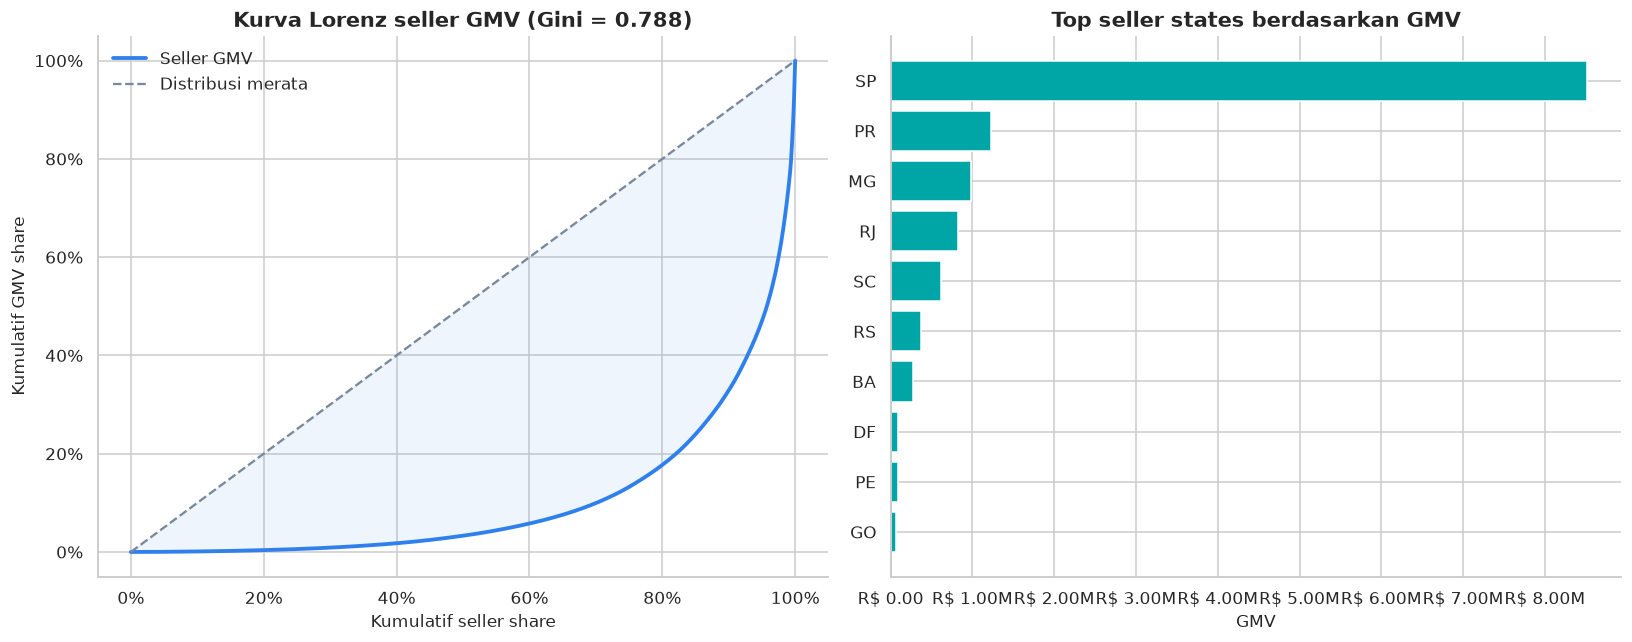

**Insight:** credit card menyumbang **78.5%** dari payment value. Di sisi supply, 10 seller terbesar menguasai **13.3%** GMV dan 100 seller terbesar menguasai **45.5%**; Gini seller GMV = **0.788**. Distribusi GMV seller cukup timpang, tetapi top seller tidak mendominasi seluruh marketplace secara mutlak.

In [17]:
seller_perf = (
    delivered_seller_orders.groupby("seller_id", as_index=False)
    .agg(
        orders=("order_id", "nunique"),
        items=("items", "sum"),
        gmv=("seller_gmv", "sum"),
        avg_review=("review_score", "mean"),
        on_time_rate=("on_time", "mean"),
        seller_state=("seller_state", "first"),
    )
    .sort_values("gmv", ascending=False)
)

def gini(values):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values) & (values >= 0)]
    if values.size == 0 or values.sum() == 0:
        return np.nan
    values = np.sort(values)
    index = np.arange(1, values.size + 1)
    return (2 * np.sum(index * values) / (values.size * values.sum())) - (values.size + 1) / values.size

seller_gini = gini(seller_perf["gmv"])
top10_seller_share = seller_perf.head(10)["gmv"].sum() / seller_perf["gmv"].sum()
top100_seller_share = seller_perf.head(100)["gmv"].sum() / seller_perf["gmv"].sum()

seller_sorted = np.sort(seller_perf["gmv"].to_numpy())
lorenz = np.insert(np.cumsum(seller_sorted) / seller_sorted.sum(), 0, 0)
seller_share = np.linspace(0, 1, len(lorenz))

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
axes[0].plot(seller_share, lorenz, color=BLUE, linewidth=2.5, label="Seller GMV")
axes[0].plot([0, 1], [0, 1], linestyle="--", color=GREY, label="Distribusi merata")
axes[0].fill_between(seller_share, lorenz, seller_share, color=BLUE, alpha=0.08)
axes[0].set_title(f"Kurva Lorenz seller GMV (Gini = {seller_gini:.3f})")
axes[0].set_xlabel("Kumulatif seller share")
axes[0].set_ylabel("Kumulatif GMV share")
axes[0].xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[0].legend()

seller_state_perf = seller_perf.groupby("seller_state", as_index=False).agg(sellers=("seller_id", "nunique"), gmv=("gmv", "sum"))
seller_state_perf = seller_state_perf.nlargest(10, "gmv").sort_values("gmv")
axes[1].barh(seller_state_perf["seller_state"], seller_state_perf["gmv"], color=TEAL)
axes[1].set_title("Top seller states berdasarkan GMV")
axes[1].set_xlabel("GMV")
axes[1].xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: format_brl(x)))
plt.tight_layout()
plt.show()

display(Markdown(
    f"**Insight:** credit card menyumbang **{payment_mix.iloc[0]['value_share']:.1%}** dari payment value. "
    f"Di sisi supply, 10 seller terbesar menguasai **{top10_seller_share:.1%}** GMV dan 100 seller terbesar "
    f"menguasai **{top100_seller_share:.1%}**; Gini seller GMV = **{seller_gini:.3f}**. "
    "Distribusi GMV seller cukup timpang, tetapi top seller tidak mendominasi seluruh marketplace secara mutlak."
))

> **Interpretasi output Cell Kode 17:** Gini GMV seller sebesar 0,788 menunjukkan distribusi yang timpang. Namun, top 10 seller hanya menyumbang 13,3% dan top 100 seller 45,5%, sehingga GMV tidak sepenuhnya bergantung pada beberapa seller saja. SP mendominasi GMV seller berdasarkan lokasi, selaras dengan konsentrasi aktivitas e-commerce di wilayah tersebut.

# **10. Kesimpulan Eksekutif dan Rekomendasi**


**Tujuan:** Menggabungkan temuan lintas analisis menjadi ringkasan yang siap dipakai dalam portofolio atau presentasi bisnis.

**Tindakan yang dilakukan:**

1. Mengambil variabel hasil dari analisis tren, kategori, delivery, retention, wilayah, dan seller.
2. Menampilkan enam temuan utama menggunakan angka yang dihitung dinamis.
3. Menyusun prioritas P0, P1, dan P2 serta rekomendasi eksperimen.

**Alasan:** Analisis data menjadi bernilai ketika temuan diterjemahkan menjadi keputusan yang terurut dan dapat diuji.


In [18]:
display(Markdown(f'''
### Temuan utama

1. **Pertumbuhan:** delivered orders Januari–Agustus 2018 tumbuh **{order_yoy:.1%} YoY** dan product GMV tumbuh **{gmv_yoy:.1%} YoY**.
2. **Portofolio produk:** `{top_unit_category['category']}` unggul dalam unit, sedangkan `{top_gmv_category['category']}` unggul dalam GMV; strategi stok dan promosi tidak boleh memakai satu ranking saja.
3. **Pain point terbesar:** late orders mempunyai low-rating rate **{late_low:.1%}**, sekitar **{low_rating_multiplier:.1f}×** on-time orders. Ketepatan estimasi dan exception handling adalah peluang perbaikan paling jelas.
4. **Retention gap:** repeat-customer rate hanya **{repeat_customer_rate:.2%}** dan month-1 cohort retention sekitar **{month1_retention:.2%}**.
5. **Wilayah inti:** `{largest_state['customer_state']}` menyumbang **{largest_state['order_share']:.1%}** delivered orders, sehingga peningkatan logistik di koridor ber-volume besar akan memberi leverage tinggi.
6. **Marketplace supply:** top 100 seller menyumbang **{top100_seller_share:.1%}** GMV; seller bernilai tinggi perlu program account management, tetapi long tail tetap penting bagi variasi katalog.

### Prioritas tindakan

- **P0 — Delivery control tower:** buat alert untuk order yang mendekati estimated delivery date, prioritaskan state ber-volume tinggi dengan on-time rate rendah, dan ukur low-rating rate per late-order bucket.
- **P1 — Repeat purchase program:** targetkan `High-Value One-Time` dan `Recent One-Time` dengan rekomendasi kategori berikutnya, voucher pembelian kedua, dan lifecycle messaging dalam 30 hari.
- **P1 — Category playbook:** lindungi ketersediaan kategori volume tinggi; optimalkan pricing/assortment kategori GMV tinggi; evaluasi kategori tail berdasarkan margin dan peran katalog, bukan volume saja.
- **P2 — Seller development:** beri scorecard berkala untuk seller dengan kombinasi GMV besar, rating rendah, dan on-time rate rendah; validasi penyebab sebelum memberi penalti karena keterlambatan tidak selalu berasal dari seller.
- **Eksperimen:** gunakan A/B test atau pilot regional untuk mengukur dampak program; analisis observasional ini mengidentifikasi prioritas, bukan kausalitas.
'''))


### Temuan utama

1. **Pertumbuhan:** delivered orders Januari–Agustus 2018 tumbuh **139.9% YoY** dan product GMV tumbuh **141.1% YoY**.
2. **Portofolio produk:** `bed_bath_table` unggul dalam unit, sedangkan `health_beauty` unggul dalam GMV; strategi stok dan promosi tidak boleh memakai satu ranking saja.
3. **Pain point terbesar:** late orders mempunyai low-rating rate **54.0%**, sekitar **5.9×** on-time orders. Ketepatan estimasi dan exception handling adalah peluang perbaikan paling jelas.
4. **Retention gap:** repeat-customer rate hanya **3.00%** dan month-1 cohort retention sekitar **0.48%**.
5. **Wilayah inti:** `SP` menyumbang **42.0%** delivered orders, sehingga peningkatan logistik di koridor ber-volume besar akan memberi leverage tinggi.
6. **Marketplace supply:** top 100 seller menyumbang **45.5%** GMV; seller bernilai tinggi perlu program account management, tetapi long tail tetap penting bagi variasi katalog.

### Prioritas tindakan

- **P0 — Delivery control tower:** buat alert untuk order yang mendekati estimated delivery date, prioritaskan state ber-volume tinggi dengan on-time rate rendah, dan ukur low-rating rate per late-order bucket.
- **P1 — Repeat purchase program:** targetkan `High-Value One-Time` dan `Recent One-Time` dengan rekomendasi kategori berikutnya, voucher pembelian kedua, dan lifecycle messaging dalam 30 hari.
- **P1 — Category playbook:** lindungi ketersediaan kategori volume tinggi; optimalkan pricing/assortment kategori GMV tinggi; evaluasi kategori tail berdasarkan margin dan peran katalog, bukan volume saja.
- **P2 — Seller development:** beri scorecard berkala untuk seller dengan kombinasi GMV besar, rating rendah, dan on-time rate rendah; validasi penyebab sebelum memberi penalti karena keterlambatan tidak selalu berasal dari seller.
- **Eksperimen:** gunakan A/B test atau pilot regional untuk mengukur dampak program; analisis observasional ini mengidentifikasi prioritas, bukan kausalitas.


**Interpretasi:**

Cell ini tidak membuat metrik baru; seluruh angka berasal dari cell sebelumnya. Prioritas tertinggi diarahkan pada pengendalian late delivery, kemudian second-purchase program, category playbook, dan seller development. Rekomendasi A/B test menegaskan bahwa analisis observasional perlu dilanjutkan dengan pengukuran kausal.

# **11. Batasan Analisis**

- Data bersifat historis (2016-2018) dan dianonimkan; temuan tidak otomatis mewakili kondisi pasar saat ini.
- Dataset tidak memuat margin, biaya seller, biaya promosi, inventory, traffic, atau conversion funnel. Karena itu GMV bukan profit.
- `payment_value` mencakup pembayaran pelanggan, sedangkan `product_gmv` hanya harga item. `order_value` mencakup harga produk + freight dan menjadi basis AOV.
- Ulasan adalah outcome pascatransaksi dan tidak tersedia untuk semua order. Hubungan delivery-rating bersifat asosiasi.
- Analisis seller memakai outcome pada level order; untuk multi-seller order, keterlambatan tidak dapat diatribusikan secara sempurna kepada satu seller.
- Bulan awal/akhir yang parsial dikeluarkan dari perbandingan tren bulanan penuh.

# **12. Opsional: Ekspor Tabel Analitik**


**Tujuan:** Memberi pilihan untuk menyimpan tabel hasil analisis sebagai CSV tanpa menciptakan file tambahan secara otomatis.

**Tindakan yang dilakukan:**

1. Menetapkan `EXPORT_TABLES = False` sebagai nilai aman bawaan.
2. Jika diubah menjadi `True`, membuat folder `outputs/`.
3. Menyimpan order fact, category performance, state performance, RFM summary, dan seller performance.

**Alasan:** Ekspor opsional menjaga notebook tetap bersih, tetapi menyediakan data siap pakai untuk dashboard atau analisis lanjutan.

**Output yang diharapkan:** Pesan bahwa ekspor dinonaktifkan; tidak ada file tambahan yang dibuat.

In [19]:
EXPORT_TABLES = False  # Ubah ke True jika ingin membuat file CSV turunan.

if EXPORT_TABLES:
    export_dir = Path("outputs")
    export_dir.mkdir(exist_ok=True)
    order_fact.to_csv(export_dir / "order_fact.csv", index=False)
    category_perf.to_csv(export_dir / "category_performance.csv", index=False)
    state_perf.to_csv(export_dir / "state_performance.csv", index=False)
    segment_summary.to_csv(export_dir / "rfm_segment_summary.csv", index=False)
    seller_perf.to_csv(export_dir / "seller_performance.csv", index=False)
    print(f"Tabel tersimpan di: {export_dir.resolve()}")
else:
    print("Ekspor dinonaktifkan. Set EXPORT_TABLES = True bila diperlukan.")

Ekspor dinonaktifkan. Set EXPORT_TABLES = True bila diperlukan.


**Interpretasi:**

Pada eksekusi saat ini ekspor dinonaktifkan, sehingga notebook hanya menghasilkan output visual dan tabel di dalam file. Pengguna dapat mengubah flag menjadi `True` ketika membutuhkan CSV untuk dashboard atau portofolio web.

---
**Selesai.**

Notebook ini dirancang agar dapat dijalankan ulang dari atas ke bawah menggunakan Python 3.11 setelah dependency pada `requirements-notebook.txt` dipasang dan sembilan CSV Olist diletakkan di folder notebook, `data/`, atau `project_sources/`. Anda juga dapat menetapkan environment variable `ECOMMERCE_DATA_DIR` ke folder dataset.